# Phân Tích Rủi Ro Tín Dụng – Nova Bank

**Báo cáo nghiên cứu:** Ứng dụng học máy trong dự đoán và phân tích rủi ro tín dụng

---


# CHƯƠNG 1: GIỚI THIỆU

---


## 1.1. Sự Cần Thiết của Chủ Đề Nghiên Cứu

Rủi ro tín dụng là một trong những thách thức cốt lõi mà các tổ chức tài chính phải đối mặt hàng ngày. Khi một khoản vay không được hoàn trả đúng hạn, ngân hàng không chỉ chịu tổn thất về vốn gốc và lãi suất mà còn phải trích lập dự phòng, ảnh hưởng trực tiếp đến lợi nhuận và tỷ lệ an toàn vốn. Tại Nova Bank, với tỷ lệ nợ quá hạn lên đến khoảng 21,8% – cao hơn gấp 3 đến 7 lần so với chuẩn ngành cho vay tiêu dùng thông thường (3–8%) – việc xây dựng một hệ thống đánh giá rủi ro hiệu quả trở nên cấp thiết hơn bao giờ hết.

Các phương pháp thẩm định tín dụng truyền thống dựa trên quy tắc cứng (rule-based) thường bỏ sót những mẫu phức tạp, phi tuyến tính trong hành vi tài chính của người vay. Sự phát triển của khoa học dữ liệu và học máy (machine learning) mở ra cơ hội phân tích đồng thời hàng chục biến số, phát hiện các yếu tố rủi ro tiềm ẩn và xây dựng mô hình dự đoán có độ chính xác cao hơn. Nghiên cứu này được thực hiện nhằm hỗ trợ Nova Bank chuyển đổi từ quy trình thẩm định thủ công sang mô hình ra quyết định dựa trên dữ liệu, qua đó giảm thiểu tổn thất tín dụng và cải thiện chất lượng danh mục cho vay.

---


## 1.2. Xác Định Mục Tiêu Nghiên Cứu

Nghiên cứu này hướng đến ba mục tiêu chính:

**Mục tiêu 1 – Phân tích và mô tả dữ liệu:**
Khám phá phân phối, cấu trúc và mối quan hệ giữa các biến trong tập dữ liệu 32.581 hồ sơ vay; xác định các nhân tố nhân khẩu học, tài chính và lịch sử tín dụng có liên quan đến xác suất nợ quá hạn.

**Mục tiêu 2 – Xây dựng và đánh giá mô hình dự đoán:**
Huấn luyện và so sánh ba mô hình học máy (Logistic Regression, Random Forest, Gradient Boosting) trên tập dữ liệu đã qua tiền xử lý; lựa chọn mô hình tối ưu dựa trên các chỉ số ROC-AUC, Recall, F1-Score và AUC-PR.

**Mục tiêu 3 – Đề xuất khuyến nghị thực tiễn:**
Dựa trên kết quả phân tích và mô hình, đưa ra các khuyến nghị cụ thể về chính sách phê duyệt tín dụng, quản lý danh mục cho vay và hệ thống cảnh báo sớm cho Nova Bank.

---


## 1.3. Dữ Liệu và Phương Pháp Nghiên Cứu

### 1.3.1. Dữ liệu

Tập dữ liệu được sử dụng trong nghiên cứu này gồm **32.581 hồ sơ vay cá nhân** tại ba quốc gia: Mỹ, Anh và Canada, với **29 biến** bao gồm thông tin nhân khẩu học, tài chính và lịch sử tín dụng.

| Nhóm biến | Các biến chính |
|-----------|---------------|
| Nhân khẩu học | `person_age`, `gender`, `marital_status`, `education_level`, `country` |
| Tài chính | `person_income`, `loan_amnt`, `loan_int_rate`, `loan_percent_income`, `debt_to_income_ratio` |
| Lịch sử tín dụng | `cb_person_cred_hist_length`, `cb_person_default_on_file`, `past_delinquencies` |
| Đặc điểm khoản vay | `loan_grade`, `loan_intent`, `person_home_ownership`, `employment_type` |

Biến mục tiêu (`loan_status`): nhận giá trị `1` = Nợ quá hạn (Default) hoặc `0` = Trả đúng hạn.

### 1.3.2. Phương pháp nghiên cứu

Nghiên cứu được thực hiện theo quy trình gồm bốn giai đoạn:

**Giai đoạn 1 – Tiền xử lý dữ liệu:**
Xử lý giá trị thiếu bằng phương pháp điền theo trung vị có điều kiện (cho `loan_int_rate`) và trung vị toàn tập (cho `person_emp_length`); phát hiện và xử lý outlier bằng phương pháp IQR kết hợp capping; tạo các biến phân nhóm mới (`age_group`, `income_group`).

**Giai đoạn 2 – Phân tích khám phá (EDA):**
Phân tích đơn biến và đa biến để xác định các yếu tố ảnh hưởng đến tỷ lệ default; kiểm định thống kê Chi-square (biến phân loại) và Mann-Whitney U (biến số) để xác nhận ý nghĩa thống kê.

**Giai đoạn 3 – Xây dựng mô hình:**
Chia tập dữ liệu theo tỷ lệ 80/20 với chiến lược Stratified sampling; áp dụng SMOTE để xử lý mất cân bằng lớp; huấn luyện ba mô hình: Logistic Regression (baseline), Random Forest và Gradient Boosting; đánh giá thông qua cross-validation 5-fold và các chỉ số hiệu suất trên tập test.

**Giai đoạn 4 – Phân tích ngưỡng và phân khúc:**
Phân tích độ nhạy của ngưỡng quyết định (threshold sensitivity); phân khúc người vay thành ba nhóm rủi ro dựa trên điểm tổng hợp; đề xuất chiến lược quản lý tín dụng cho từng nhóm.

---


# CHƯƠNG 2: KẾT QUẢ NGHIÊN CỨU VÀ THẢO LUẬN

---


## 2.1. Tiền Xử Lý Dữ Liệu và Mô Tả Dữ Liệu

---


### 2.1.1. Import Thư Viện và Cấu Hình

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Cấu hình style biểu đồ
plt.rcParams.update({
    'figure.facecolor': '#F4F6FA',
    'axes.facecolor':   '#F4F6FA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})
sns.set_palette("deep")

# Bảng màu chủ đề
C_SAFE   = '#1A9C7B'   # Xanh lá – an toàn
C_RISK   = '#C0392B'   # Đỏ – rủi ro
C_BLUE   = '#2471A3'
C_ORANGE = '#CA6F1E'
C_PURPLE = '#7D3C98'
PALETTE2 = [C_SAFE, C_RISK]

print("Cấu hình hoàn tất.")


Cấu hình hoàn tất.


### 2.1.2. Tải Dữ Liệu và Khám Phá Ban Đầu

In [2]:
# Đọc dữ liệu
FILE = 'Credit_Risk_Dataset.xlsx'
df = pd.read_excel(FILE)

print(f"Kích thước dữ liệu: {df.shape[0]:,} hàng x {df.shape[1]} cột")
print()
df.head()


Kích thước dữ liệu: 32,581 hàng x 29 cột



,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,...,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,...,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,...,42.8864,-78.8784,Part-time,36,0.643382,15626.153439,0.930628,4,0.228103,0


In [3]:
# Thông tin tổng quan về kiểu dữ liệu và giá trị null
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  object 
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  object 
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  object 
 6   loan_grade                  32581 non-null  object 
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  object 
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender                      325

In [4]:
# Thống kê mô tả
df.describe(include='all').T.style.background_gradient(cmap='Blues', subset=['mean','std','50%'])


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
client_ID,32581,32581,CUST_32581,1,nan,nan,nan,nan,nan,nan,nan
person_age,32581.000000,nan,nan,nan,27.734600,6.348078,20.000000,23.000000,26.000000,30.000000,144.000000
person_income,32581.000000,nan,nan,nan,66074.848470,61983.119168,4000.000000,38500.000000,55000.000000,79200.000000,6000000.000000
person_home_ownership,32581,4,RENT,16446,nan,nan,nan,nan,nan,nan,nan
person_emp_length,31686.000000,nan,nan,nan,4.789686,4.142630,0.000000,2.000000,4.000000,7.000000,123.000000
loan_intent,32581,6,EDUCATION,6453,nan,nan,nan,nan,nan,nan,nan
loan_grade,32581,7,A,10777,nan,nan,nan,nan,nan,nan,nan
loan_amnt,32581.000000,nan,nan,nan,9589.371106,6322.086646,500.000000,5000.000000,8000.000000,12200.000000,35000.000000
loan_int_rate,29465.000000,nan,nan,nan,11.011695,3.240459,5.420000,7.900000,10.990000,13.470000,23.220000
loan_status,32581.000000,nan,nan,nan,0.218164,0.413006,0.000000,0.000000,0.000000,0.000000,1.000000


In [5]:
# Kiểm tra giá trị thiếu
missing = df.isnull().sum()
missing = missing[missing > 0]
pct     = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'So luong thieu': missing, '% thieu': pct})
print("=== Gia tri thieu ===")
display(miss_df.style.bar(subset=['% thieu'], color='#C0392B'))


=== Gia tri thieu ===


,So luong thieu,% thieu
person_emp_length,895,2.750000
loan_int_rate,3116,9.560000


**Nhận xét tổng quan dữ liệu:**

Tập dữ liệu gồm 32.581 hồ sơ vay với 29 biến, bao gồm cả biến số (tuổi, thu nhập, lãi suất...) và biến phân loại (mục đích vay, xếp hạng, loại việc làm...).

Biến mục tiêu `loan_status` nhận giá trị nhị phân: 1 là Nợ quá hạn (Default), 0 là Trả đúng hạn. Đây là bài toán phân loại nhị phân với dữ liệu không cân bằng.

Một số điểm cần lưu ý trước khi phân tích:
- `loan_int_rate` và `person_emp_length` có giá trị thiếu cần xử lý trước.
- Các biến như `person_age`, `person_income`, `person_emp_length` có thể chứa outlier cực trội (ví dụ: tuổi trên 100, thu nhập bất thường).
- `country` gồm 3 quốc gia: Mỹ, Anh, Canada. Cần kiểm tra xem quốc gia có ảnh hưởng đến rủi ro hay không.
- `loan_grade` (A–G) là biến xếp hạng tín dụng quan trọng, phân loại rủi ro tăng dần từ A đến G.

---


### 2.1.3. Làm Sạch và Tiền Xử Lý Dữ Liệu

#### a) Xử lý giá trị thiếu và tạo biến mới

In [6]:
# Điền giá trị thiếu
df['loan_int_rate']     = df['loan_int_rate'].fillna(
    df.groupby('loan_grade')['loan_int_rate'].transform('median'))
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# Tạo nhóm tuổi
bins_age   = [17, 25, 35, 45, 55, 100]
labels_age = ['18-25','26-35','36-45','46-55','56+']
df['age_group'] = pd.cut(df['person_age'], bins=bins_age, labels=labels_age)

# Tạo nhóm thu nhập
bins_inc   = [0, 30000, 60000, 90000, 120000, df['person_income'].max()+1]
labels_inc = ['<30K','30-60K','60-90K','90-120K','>120K']
df['income_group'] = pd.cut(df['person_income'], bins=bins_inc, labels=labels_inc)

# Nhãn mục tiêu
df['default_label'] = df['loan_status'].map({0:'Trả đúng hạn', 1:'Nợ quá hạn'})

print("Lam sach du lieu hoan tat.")
print(f"  Kich thuoc sau khi lam sach: {df.shape}")


Lam sach du lieu hoan tat.
  Kich thuoc sau khi lam sach: (32581, 32)


**Nhận xét về xử lý giá trị thiếu:**

- `loan_int_rate` được điền theo trung vị của từng nhóm xếp hạng thay vì trung vị toàn bộ, đảm bảo tính nhất quán giữa rủi ro và lãi suất. Nếu biến này có tỷ lệ thiếu cao (trên 10%), cần kiểm tra thêm xem sự thiếu có mang tính hệ thống không (ví dụ: thiếu nhiều ở nhóm xếp hạng thấp).
- `person_emp_length` được điền bằng trung vị toàn tập dữ liệu, phù hợp cho biến liên tục không có nhóm rõ ràng.
- Các biến `age_group` và `income_group` được tạo mới để phân tích phi tuyến, vì rủi ro không tăng đơn điệu theo tuổi hay thu nhập.

---


#### b) Phát hiện và xử lý Outlier

In [7]:
# PHÁT HIỆN OUTLIER BẰNG PHƯƠNG PHÁP IQR
def detect_outliers_iqr(df, cols):
    result = []
    for col in cols:
        series = df[col].dropna()
        Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
        IQR    = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n_out  = ((series < lower) | (series > upper)).sum()
        pct    = n_out / len(df) * 100
        result.append({
            'Cot'        : col,
            'Q1'         : round(Q1, 2),
            'Q3'         : round(Q3, 2),
            'IQR'        : round(IQR, 2),
            'Lower Bound': round(lower, 2),
            'Upper Bound': round(upper, 2),
            'So Outlier' : int(n_out),
            'Ty le %'    : round(pct, 2)
        })
    return pd.DataFrame(result).sort_values('Ty le %', ascending=False)

numeric_cols_check = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length', 'debt_to_income_ratio',
    'credit_utilization_ratio', 'past_delinquencies'
]

outlier_df = detect_outliers_iqr(df, numeric_cols_check)

print("=" * 65)
print("PHAT HIEN OUTLIER BANG IQR – CAC BIEN SO CHINH")
print("=" * 65)
display(outlier_df.style
        .background_gradient(subset=['Ty le %'], cmap='Reds', vmin=0, vmax=20)
        .bar(subset=['So Outlier'], color='#C0392B', vmin=0)
        .set_properties(**{'font-size': '11px'}))


PHAT HIEN OUTLIER BANG IQR – CAC BIEN SO CHINH


,Cot,Q1,Q3,IQR,Lower Bound,Upper Bound,So Outlier,Ty le %
3,loan_amnt,5000.000000,12200.000000,7200.000000,-5800.000000,23000.000000,1689,5.180000
0,person_age,23.000000,30.000000,7.000000,12.500000,40.500000,1494,4.590000
1,person_income,38500.000000,79200.000000,40700.000000,-22550.000000,140250.000000,1484,4.550000
6,cb_person_cred_hist_length,3.000000,8.000000,5.000000,-4.500000,15.500000,1142,3.510000
2,person_emp_length,2.000000,7.000000,5.000000,-5.500000,14.500000,853,2.620000
5,loan_percent_income,0.090000,0.230000,0.140000,-0.120000,0.440000,651,2.000000
9,past_delinquencies,0.000000,1.000000,1.000000,-1.500000,2.500000,464,1.420000
7,debt_to_income_ratio,0.250000,0.420000,0.170000,-0.010000,0.680000,463,1.420000
4,loan_int_rate,7.880000,13.480000,5.600000,-0.520000,21.880000,6,0.020000
8,credit_utilization_ratio,0.280000,0.730000,0.450000,-0.400000,1.400000,0,0.000000


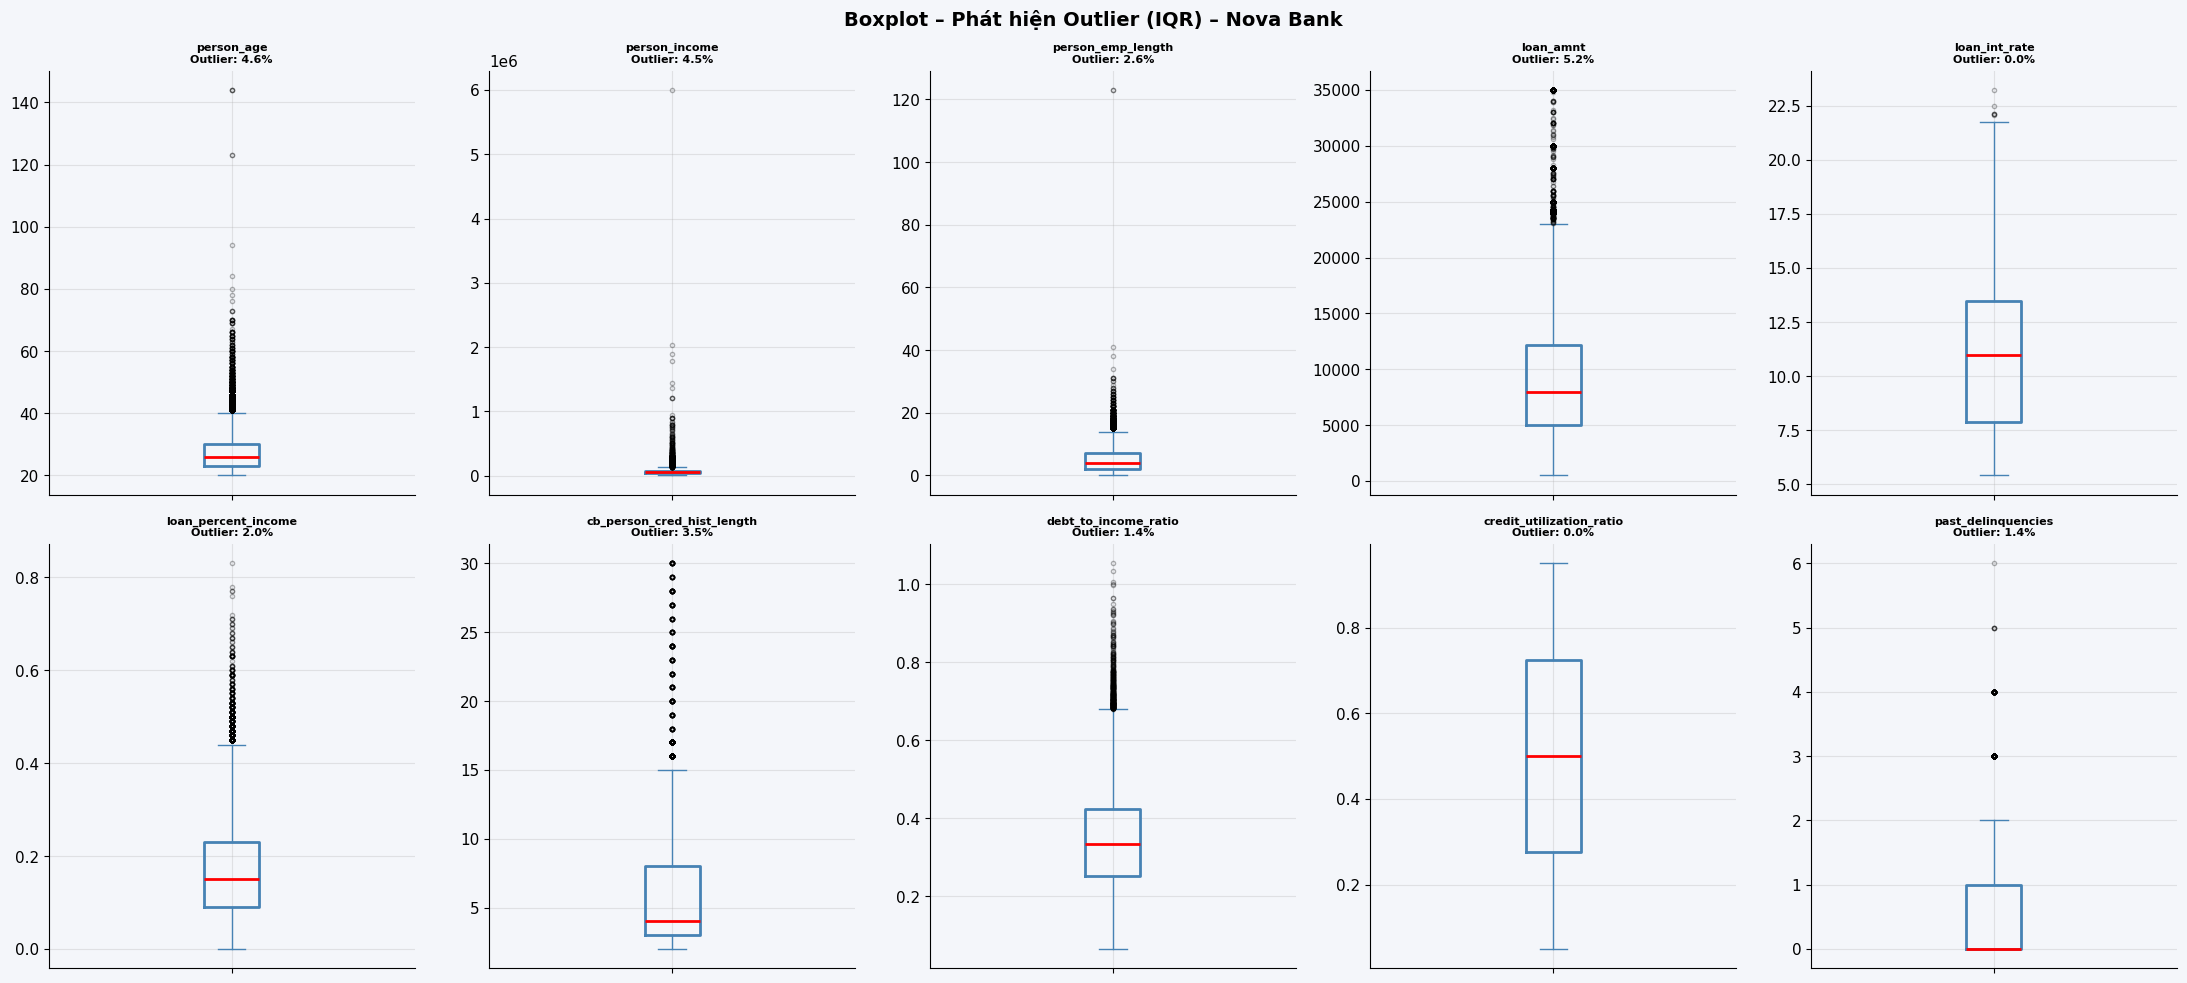

In [8]:
# Boxplot trực quan hóa outlier
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_check):
    df.boxplot(
        column=col, ax=axes[i],
        boxprops     = dict(color='steelblue', linewidth=2),
        medianprops  = dict(color='red',       linewidth=2),
        whiskerprops = dict(color='steelblue'),
        capprops     = dict(color='steelblue'),
        flierprops   = dict(marker='o', color='tomato', alpha=0.3, markersize=3)
    )
    n_out = outlier_df.loc[outlier_df['Cot'] == col, 'Ty le %']
    pct_txt = f"{n_out.values[0]:.1f}%" if len(n_out) else "0%"
    axes[i].set_title(f"{col}\nOutlier: {pct_txt}", fontsize=8, fontweight='bold')
    axes[i].tick_params(axis='x', labelbottom=False)

plt.suptitle('Boxplot – Phát hiện Outlier (IQR) – Nova Bank', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Nhận xét về Outlier:**

- `person_income` và `loan_amnt` có tỷ lệ outlier cao nhất do một số khách hàng có thu nhập hoặc khoản vay rất lớn so với phần lớn mẫu dữ liệu.
- `person_emp_length` chứa một số giá trị bất thường (ví dụ: 123 năm kinh nghiệm) – cần xử lý bằng cách cap ở ngưỡng hợp lý (40 năm).
- `person_age` có một số hồ sơ với tuổi rất cao (trên 100) – khả năng cao là lỗi nhập liệu.
- Các biến tài chính như `loan_int_rate`, `debt_to_income_ratio` có outlier nhưng thường mang ý nghĩa kinh doanh thực tế (khách hàng rủi ro cao), không nên xóa mà chỉ xử lý capping.

**Chiến lược xử lý:**
- `person_emp_length`: cap tại 40 năm (tuổi thọ nghề nghiệp thực tế)
- `person_age`: lọc bỏ hồ sơ có tuổi trên 100 (lỗi dữ liệu)
- `person_income` và `loan_amnt`: giữ nguyên (outlier hợp lệ về mặt nghiệp vụ)

---


In [9]:
# XỬ LÝ OUTLIER – CAP VÀ FILTER
df_clean = df.copy()

# Cap person_emp_length tại 40 năm
df_clean['person_emp_length'] = df_clean['person_emp_length'].clip(upper=40)

# Lọc bỏ hồ sơ tuổi bất thường (>100)
n_before = len(df_clean)
df_clean = df_clean[df_clean['person_age'] <= 100]
print(f"Loai bo {n_before - len(df_clean)} ho so co tuoi > 100")

# Flag anomaly cho person_emp_length nếu cần theo dõi
df_clean['emp_length_capped'] = (df['person_emp_length'] > 40).astype(int)

print(f"\nKich thuoc sau xu ly: {df_clean.shape}")
print(f"  person_emp_length max: {df_clean['person_emp_length'].max()}")
print(f"  person_age max: {df_clean['person_age'].max()}")


Loai bo 5 ho so co tuoi > 100

Kich thuoc sau xu ly: (32576, 33)
  person_emp_length max: 40.0
  person_age max: 94


### 2.1.4. Mô Tả Dữ Liệu và Phân Tích Khám Phá (EDA)

#### a) Tổng quan tỷ lệ nợ quá hạn

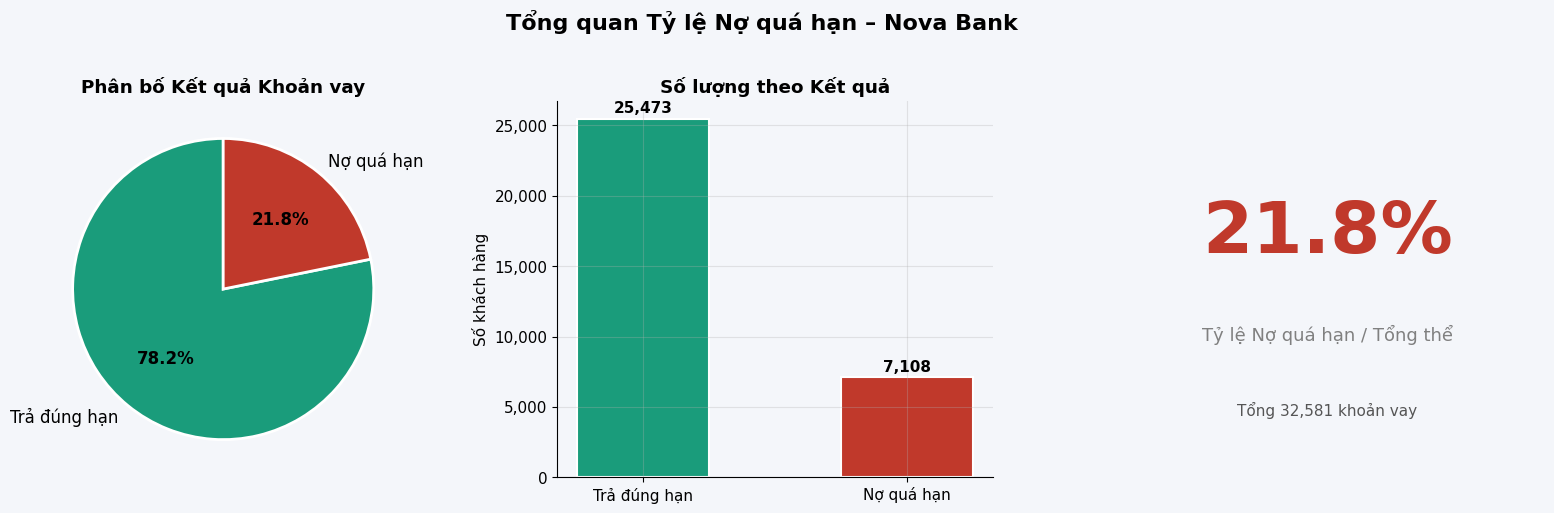


Ty le default tong the: 21.82% (7,108 / 32,581 khoan vay)


In [10]:
default_rate = df['loan_status'].mean() * 100
counts       = df['loan_status'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Tổng quan Tỷ lệ Nợ quá hạn – Nova Bank', fontsize=16, fontweight='bold', y=1.02)

# Pie chart
wedges, texts, autotexts = axes[0].pie(
    counts, labels=['Trả đúng hạn','Nợ quá hạn'],
    colors=PALETTE2, autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':12}
)
for at in autotexts: at.set_fontweight('bold')
axes[0].set_title('Phân bố Kết quả Khoản vay', fontweight='bold')

# Bar count
bars = axes[1].bar(['Trả đúng hạn','Nợ quá hạn'], counts.values,
                   color=PALETTE2, edgecolor='white', linewidth=1.5, width=0.5)
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f'{bar.get_height():,}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Số lượng theo Kết quả', fontweight='bold')
axes[1].set_ylabel('Số khách hàng')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# KPI
ax = axes[2]
ax.axis('off')
ax.text(0.5, 0.65, f'{default_rate:.1f}%', ha='center', va='center',
        fontsize=52, fontweight='bold', color=C_RISK, transform=ax.transAxes)
ax.text(0.5, 0.38, 'Tỷ lệ Nợ quá hạn / Tổng thể', ha='center', va='center',
        fontsize=13, color='gray', transform=ax.transAxes)
ax.text(0.5, 0.18, f'Tổng {len(df):,} khoản vay', ha='center', va='center',
        fontsize=11, color='#555', transform=ax.transAxes)

plt.tight_layout()
plt.show()
print(f"\nTy le default tong the: {default_rate:.2f}% ({counts[1]:,} / {len(df):,} khoan vay)")


**Nhận xét:**

| Chỉ số | Giá trị |
|--------|---------|
| Tỷ lệ nợ quá hạn tổng thể | ~21,8% |
| Số khoản vay trong tập dữ liệu | 32.581 |
| Benchmark ngành (cho vay tiêu dùng) | 3 – 8% |

Tỷ lệ ~21,8% là rất cao so với chuẩn ngành cho vay tiêu dùng thông thường, cho thấy hoặc Nova Bank đang phục vụ phân khúc rủi ro cao, hoặc quy trình thẩm định hiện tại cần được cải thiện đáng kể.

Dữ liệu không cân bằng với tỷ lệ 78,2% so với 21,8%. Nếu xây dựng mô hình dự đoán, cần áp dụng kỹ thuật xử lý như SMOTE hoặc class_weight. Mức 21,8% này là baseline quan trọng – mọi phân tích phân nhóm tiếp theo đều so sánh với mức này để xác định nhóm rủi ro cao hay thấp.

---


#### b) Phân tích theo nhân khẩu học

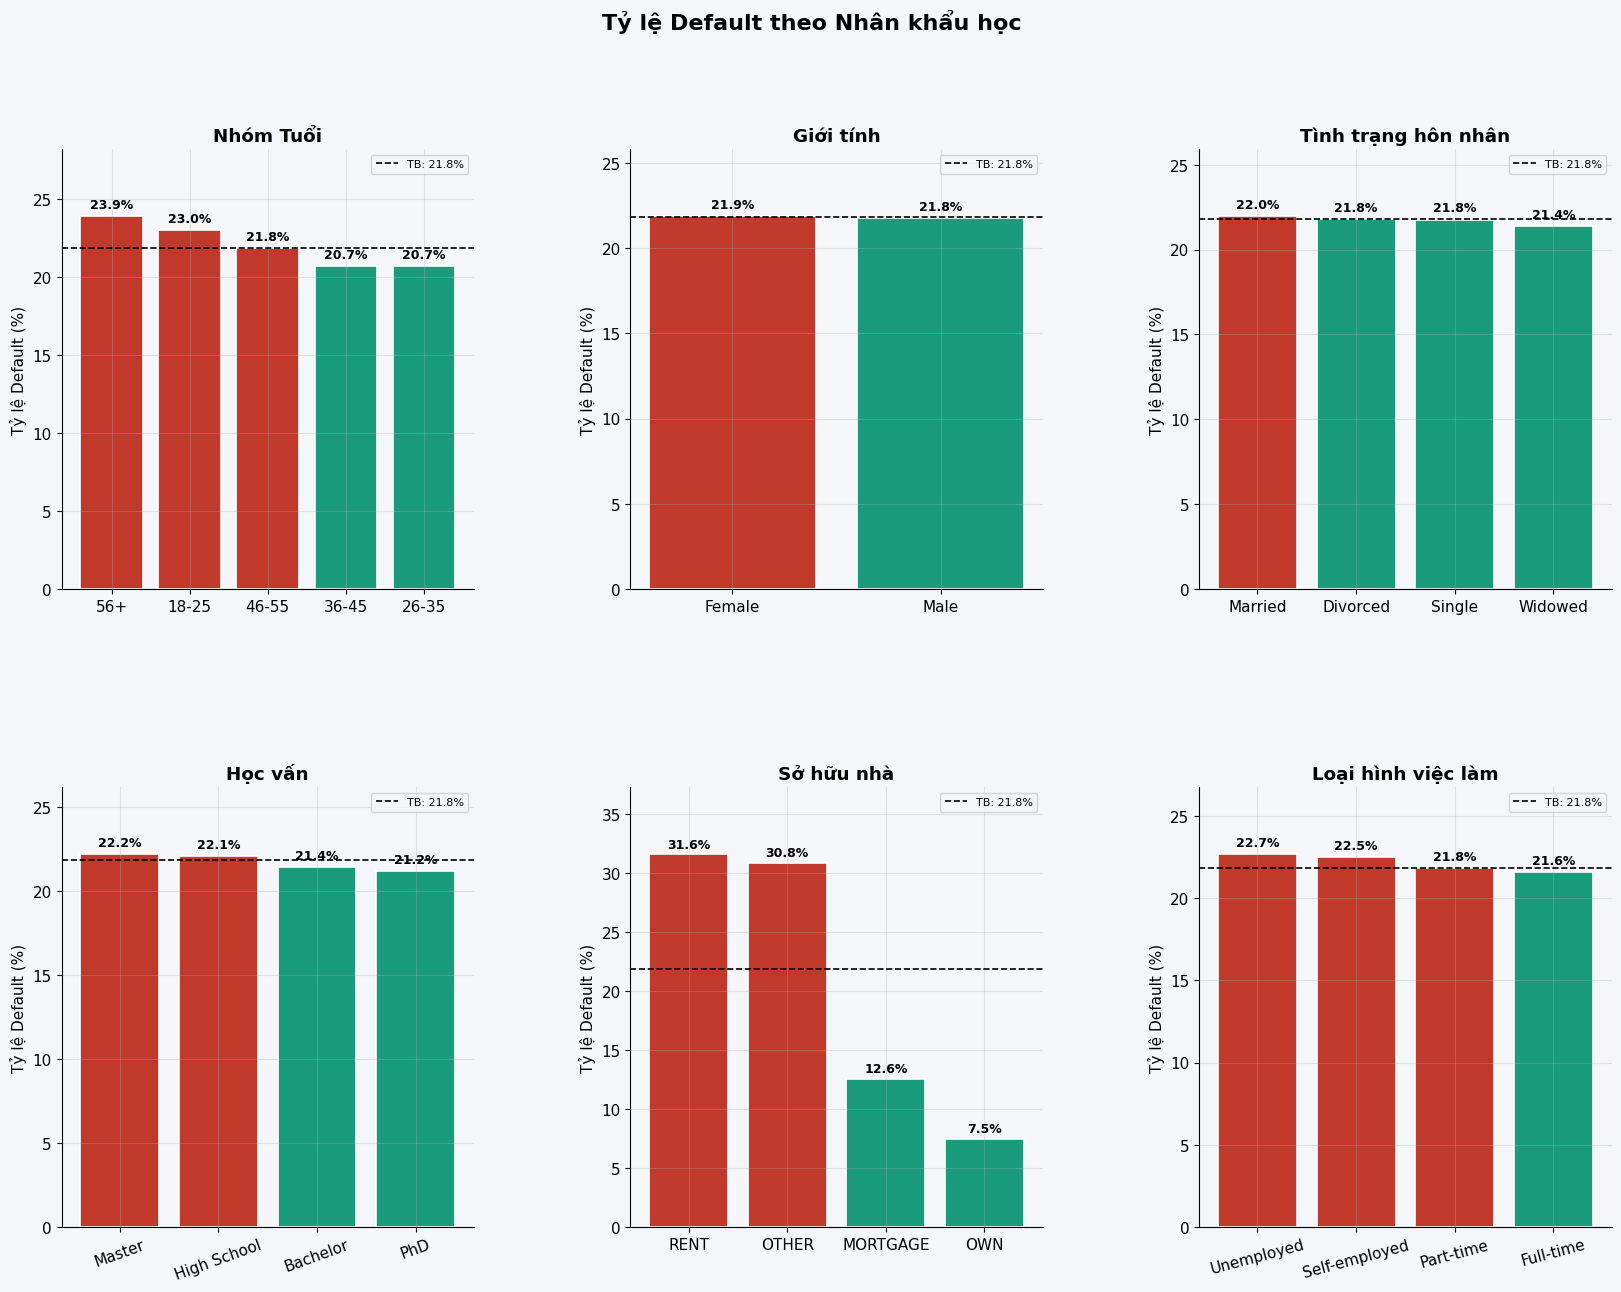

In [11]:
fig = plt.figure(figsize=(20, 14))
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle('Tỷ lệ Default theo Nhân khẩu học', fontsize=16, fontweight='bold')

def bar_default_rate(ax, col, title, rotate=0):
    grp = df.groupby(col)['loan_status'].mean().sort_values(ascending=False) * 100
    colors = [C_RISK if v > default_rate else C_SAFE for v in grp.values]
    bars = ax.bar(grp.index.astype(str), grp.values, color=colors, edgecolor='white', linewidth=1.2)
    ax.axhline(default_rate, color='black', linestyle='--', linewidth=1.2, label=f'TB: {default_rate:.1f}%')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Tỷ lệ Default (%)')
    ax.set_ylim(0, grp.max() * 1.18)
    ax.legend(fontsize=8)
    if rotate: ax.tick_params(axis='x', rotation=rotate)

ax1 = fig.add_subplot(gs[0, 0])
bar_default_rate(ax1, 'age_group', 'Nhóm Tuổi')

ax2 = fig.add_subplot(gs[0, 1])
bar_default_rate(ax2, 'gender', 'Giới tính')

ax3 = fig.add_subplot(gs[0, 2])
bar_default_rate(ax3, 'marital_status', 'Tình trạng hôn nhân')

ax4 = fig.add_subplot(gs[1, 0])
bar_default_rate(ax4, 'education_level', 'Học vấn', rotate=20)

ax5 = fig.add_subplot(gs[1, 1])
bar_default_rate(ax5, 'person_home_ownership', 'Sở hữu nhà')

ax6 = fig.add_subplot(gs[1, 2])
bar_default_rate(ax6, 'employment_type', 'Loại hình việc làm', rotate=15)

plt.show()


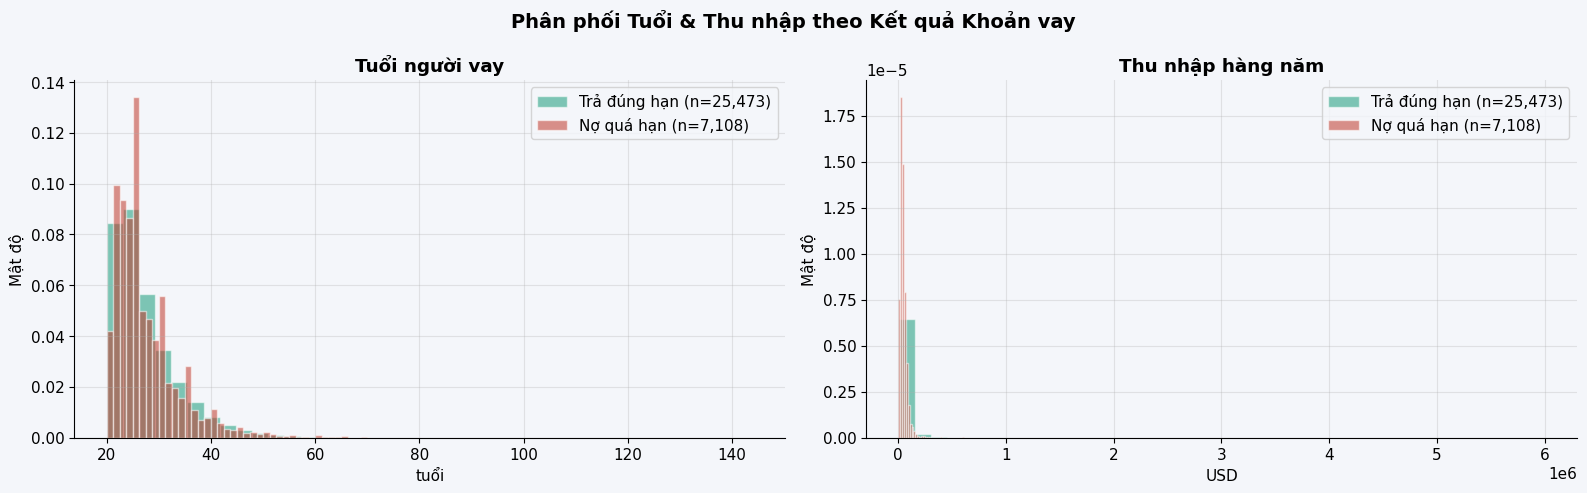

In [14]:
# Phân phối tuổi và thu nhập theo kết quả khoản vay
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Phân phối Tuổi & Thu nhập theo Kết quả Khoản vay', fontsize=14, fontweight='bold')

for i, (col, title, unit) in enumerate([
    ('person_age',    'Tuổi người vay',       'tuổi'),
    ('person_income', 'Thu nhập hàng năm',   'USD')
]):
    for status, color, label in [(0, C_SAFE, 'Trả đúng hạn'), (1, C_RISK, 'Nợ quá hạn')]:
        data = df[df['loan_status'] == status][col]
        axes[i].hist(data, bins=40, alpha=0.55, color=color, label=f'{label} (n={len(data):,})',
                     density=True, edgecolor='white')
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel(unit)
    axes[i].set_ylabel('Mật độ')
    axes[i].legend()

plt.tight_layout()
plt.show()


**Nhận xét phân tích nhân khẩu học:**

**Nhóm tuổi:** Người vay trẻ (18–25 tuổi) có tỷ lệ nợ quá hạn cao nhất do thu nhập không ổn định, ít lịch sử tín dụng và dễ gặp khó khăn tài chính bất ngờ. Nhóm 36–45 tuổi thường có tỷ lệ nợ quá hạn thấp nhất nhờ thu nhập ổn định, tài sản tích lũy và kinh nghiệm quản lý tài chính tốt hơn. Nova Bank nên áp dụng điều kiện vay chặt hơn hoặc hạn mức tín dụng thấp hơn với người vay dưới 25 tuổi, đồng thời yêu cầu người đồng bảo lãnh.

**Giới tính và hôn nhân:** Sự khác biệt theo giới tính thường không lớn về mặt thống kê – cần kiểm định Chi-square trước khi đưa vào mô hình để tránh discrimination bias. Người độc thân có thể có tỷ lệ nợ quá hạn cao hơn do thiếu nguồn thu nhập thứ hai trong gia đình.

**Việc làm và sở hữu nhà:** Người thuê nhà (RENT) thường có tỷ lệ nợ quá hạn cao hơn người sở hữu nhà (MORTGAGE/OWN) do gánh nặng chi phí sinh hoạt cao hơn và ít tài sản bảo đảm hơn. Người thất nghiệp và bán thời gian rõ ràng là nhóm rủi ro cao do thiếu nguồn thu nhập ổn định để trả nợ đúng hạn.

---


#### c) Phân tích theo mục đích và xếp hạng khoản vay

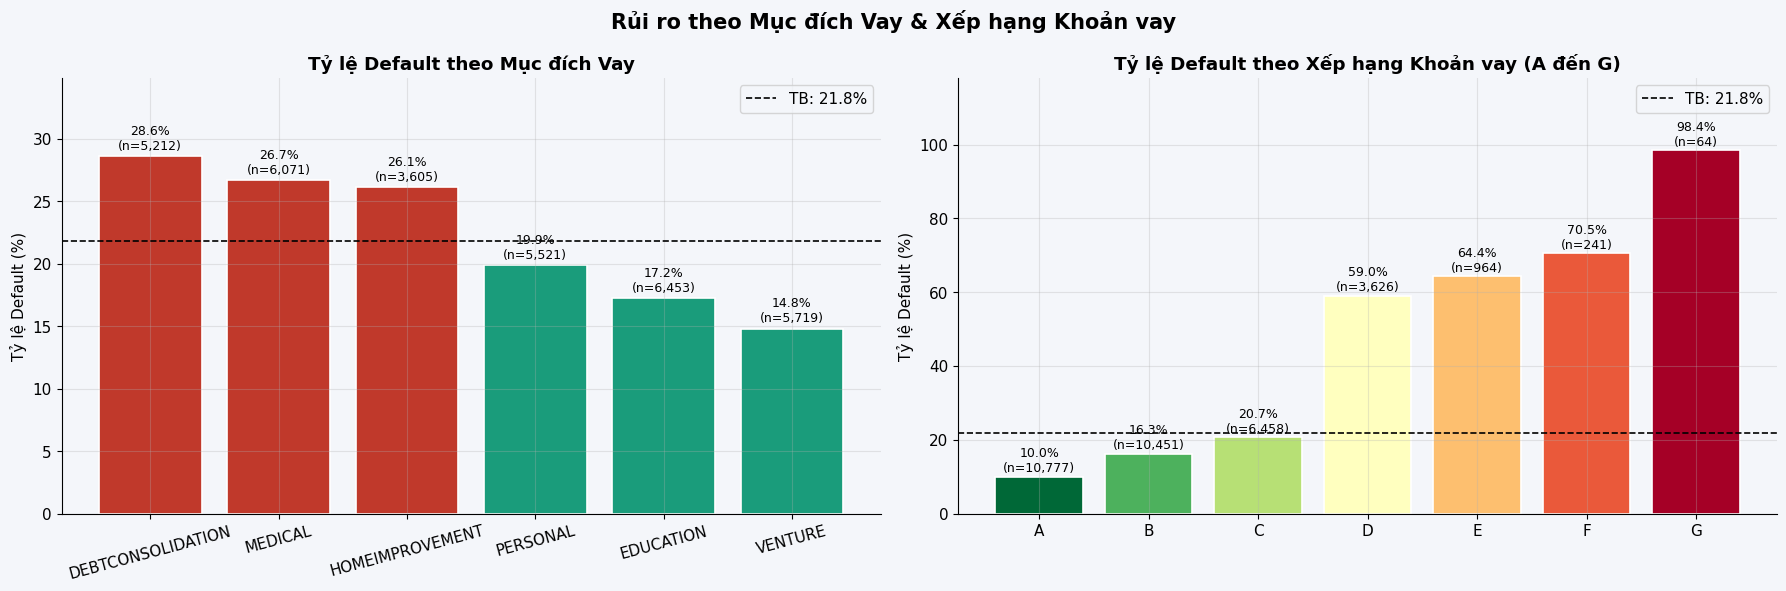

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Rủi ro theo Mục đích Vay & Xếp hạng Khoản vay', fontsize=15, fontweight='bold')

# Mục đích vay
intent_dr  = df.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False) * 100
intent_cnt = df.groupby('loan_intent')['loan_status'].count()
colors_i   = [C_RISK if v > default_rate else C_SAFE for v in intent_dr.values]
bars = axes[0].bar(intent_dr.index, intent_dr.values, color=colors_i, edgecolor='white', linewidth=1.2)
axes[0].axhline(default_rate, color='black', linestyle='--', linewidth=1.2, label=f'TB: {default_rate:.1f}%')
for bar, cnt in zip(bars, intent_cnt[intent_dr.index].values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%\n(n={cnt:,})', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Tỷ lệ Default theo Mục đích Vay', fontweight='bold')
axes[0].set_ylabel('Tỷ lệ Default (%)')
axes[0].set_ylim(0, intent_dr.max() * 1.22)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()

# Xếp hạng khoản vay
grade_order = ['A','B','C','D','E','F','G']
grade_dr  = df.groupby('loan_grade')['loan_status'].mean().reindex(grade_order) * 100
grade_cnt = df.groupby('loan_grade')['loan_status'].count().reindex(grade_order)
cmap_g = plt.cm.get_cmap('RdYlGn_r', len(grade_order))
for idx, (grade, val) in enumerate(grade_dr.items()):
    axes[1].bar(grade, val, color=cmap_g(idx), edgecolor='white', linewidth=1.2)
    axes[1].text(idx, val + 0.5, f'{val:.1f}%\n(n={grade_cnt[grade]:,})',
                 ha='center', va='bottom', fontsize=9)
axes[1].axhline(default_rate, color='black', linestyle='--', linewidth=1.2, label=f'TB: {default_rate:.1f}%')
axes[1].set_title('Tỷ lệ Default theo Xếp hạng Khoản vay (A đến G)', fontweight='bold')
axes[1].set_ylabel('Tỷ lệ Default (%)')
axes[1].set_ylim(0, grade_dr.max() * 1.2)
axes[1].legend()

plt.tight_layout()
plt.show()


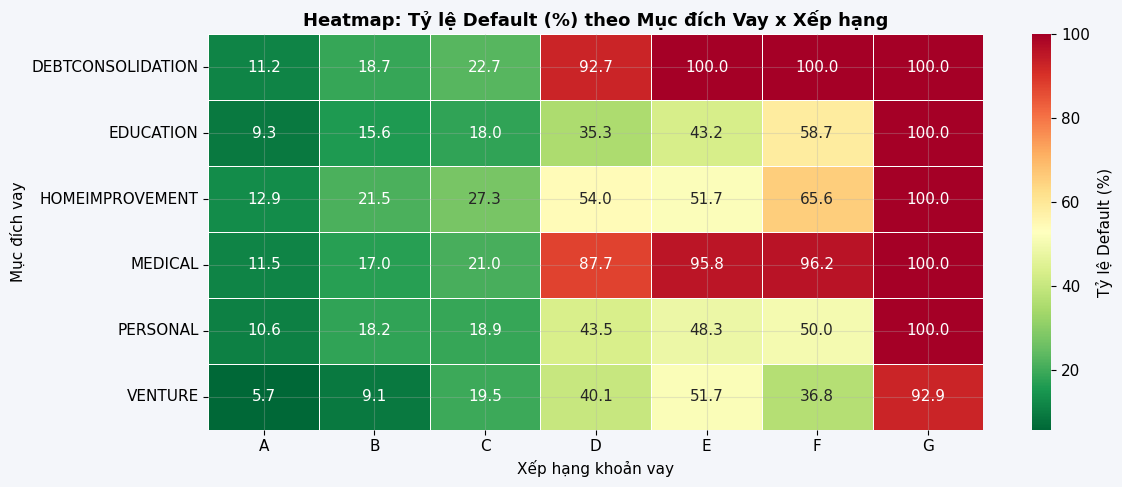

In [16]:
# Heatmap: Mục đích vay x Xếp hạng
pivot = df.pivot_table(values='loan_status', index='loan_intent', columns='loan_grade',
                       aggfunc='mean')[['A','B','C','D','E','F','G']] * 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', linewidths=0.5,
            linecolor='white', ax=ax, cbar_kws={'label': 'Tỷ lệ Default (%)'})
ax.set_title('Heatmap: Tỷ lệ Default (%) theo Mục đích Vay x Xếp hạng', fontsize=13, fontweight='bold')
ax.set_xlabel('Xếp hạng khoản vay')
ax.set_ylabel('Mục đích vay')
plt.tight_layout()
plt.show()


**Nhận xét về mục đích vay và xếp hạng:**

**Mục đích vay:**

| Mục đích | Mức rủi ro | Lý giải |
|----------|-----------|---------|
| VENTURE (Kinh doanh) | Cao nhất | Thu nhập từ kinh doanh không ổn định, phụ thuộc vào thị trường |
| EDUCATION (Giáo dục) | Cao | Thu nhập chưa có ngay sau khi vay, hoàn trả phụ thuộc vào triển vọng nghề nghiệp |
| MEDICAL (Y tế) | Trung bình | Áp lực tài chính đột ngột nhưng nhu cầu bức thiết thường được ưu tiên trả |
| HOMEIMPROVEMENT | Thấp nhất | Tăng giá trị tài sản, người vay có động lực bảo vệ nhà |
| DEBTCONSOLIDATION | Trung bình | Phụ thuộc vào tổng mức nợ và kỷ luật tài chính người vay |

**Xếp hạng khoản vay (A đến G):** Xếp hạng A và B có tỷ lệ nợ quá hạn rất thấp – đây là nhóm "vàng" của danh mục cho vay. Xếp hạng E, F, G có tỷ lệ nợ quá hạn từ 40 đến 80% – rủi ro cực kỳ cao; lãi suất cao hơn không đủ bù đắp tổn thất khi vỡ nợ.

Heatmap Mục đích × Xếp hạng là công cụ thực tiễn: ô màu đỏ đậm (ví dụ VENTURE × Grade G) là tổ hợp tệ nhất cần đặc biệt thận trọng. Khuyến nghị xem xét ngừng cấp tín dụng cho tổ hợp Grade F–G và VENTURE, hoặc yêu cầu bắt buộc tài sản bảo đảm (collateral).

---


#### d) Phân tích các chỉ số tài chính

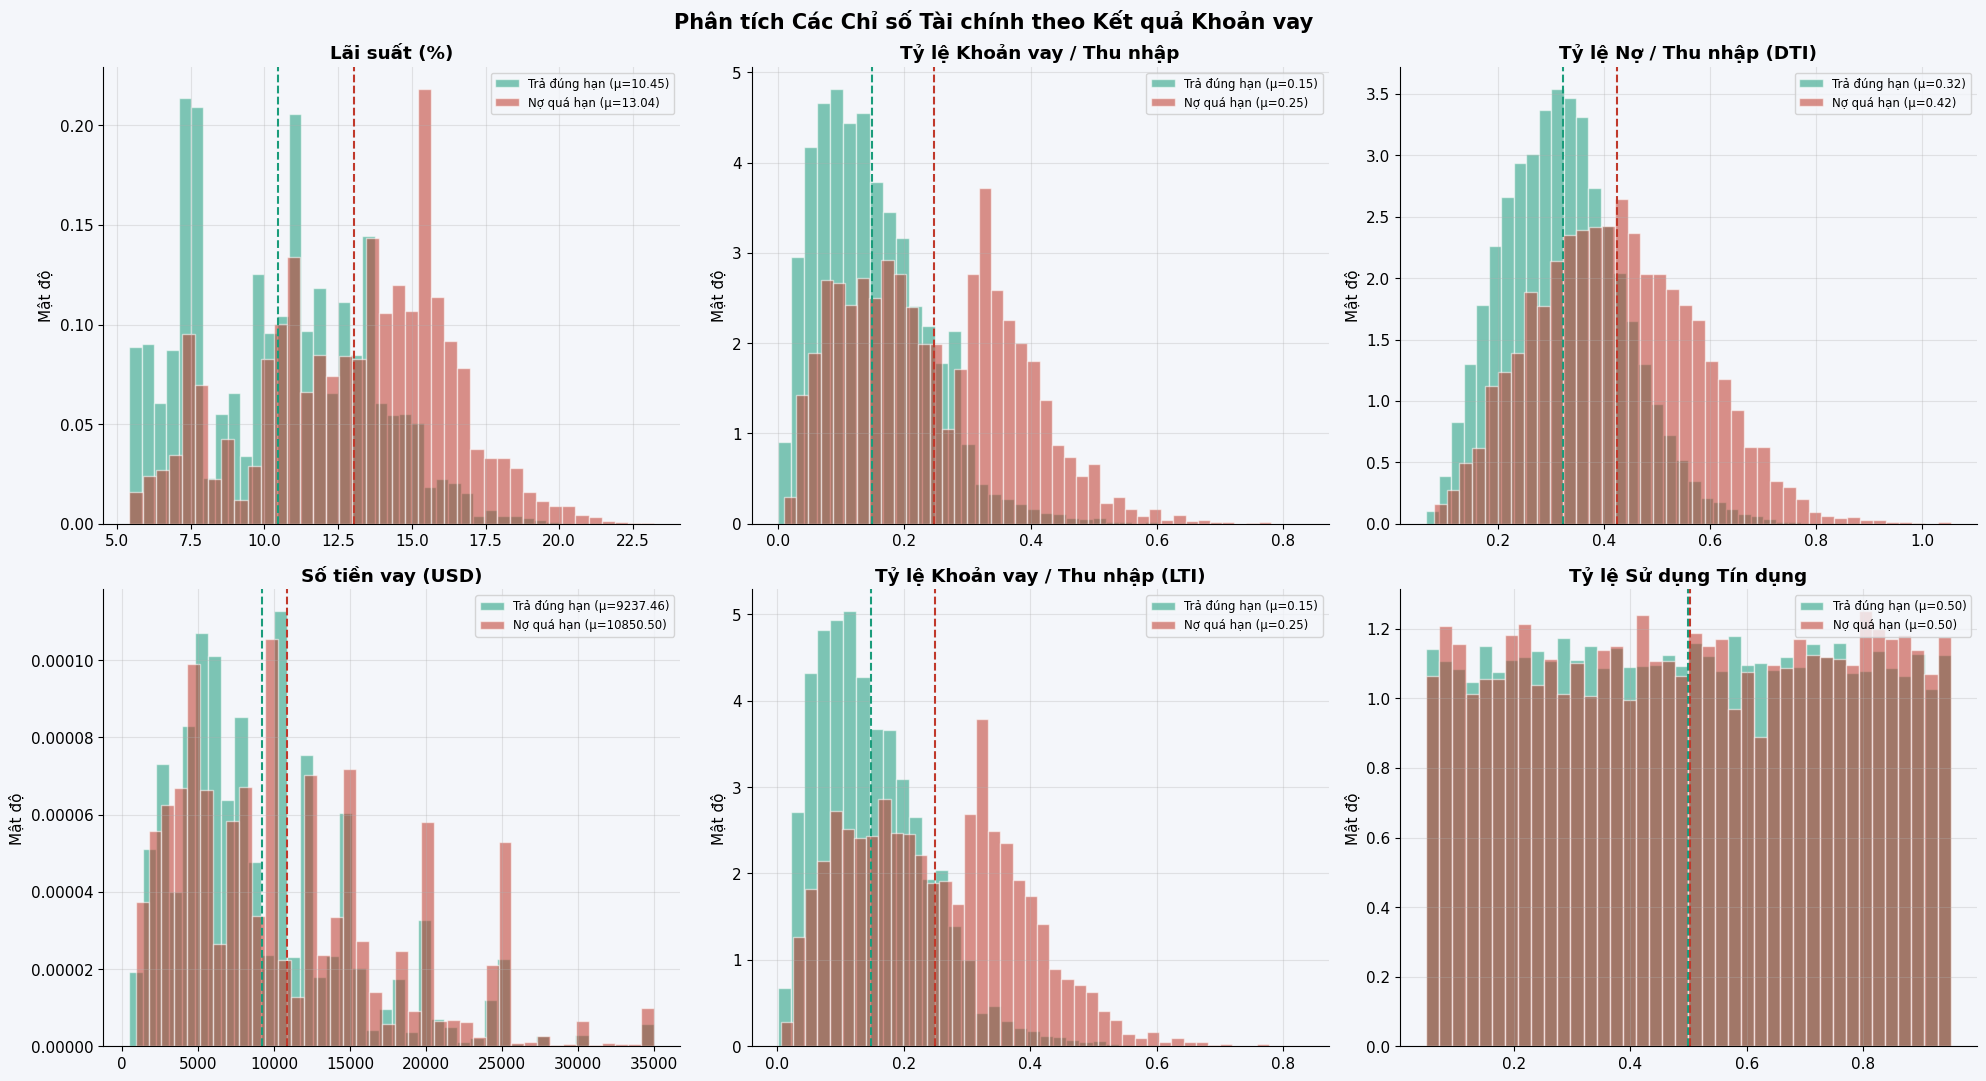

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Phân tích Các Chỉ số Tài chính theo Kết quả Khoản vay', fontsize=15, fontweight='bold')

metrics = [
    ('loan_int_rate',       'Lãi suất (%)',                        axes[0,0]),
    ('loan_percent_income', 'Tỷ lệ Khoản vay / Thu nhập',          axes[0,1]),
    ('debt_to_income_ratio','Tỷ lệ Nợ / Thu nhập (DTI)',           axes[0,2]),
    ('loan_amnt',           'Số tiền vay (USD)',                   axes[1,0]),
    ('loan_to_income_ratio','Tỷ lệ Khoản vay / Thu nhập (LTI)',    axes[1,1]),
    ('credit_utilization_ratio', 'Tỷ lệ Sử dụng Tín dụng',       axes[1,2]),
]

for col, label, ax in metrics:
    data0 = df[df['loan_status']==0][col].dropna()
    data1 = df[df['loan_status']==1][col].dropna()
    ax.hist(data0, bins=40, alpha=0.55, color=C_SAFE, density=True,
            label=f'Trả đúng hạn (μ={data0.mean():.2f})', edgecolor='white')
    ax.hist(data1, bins=40, alpha=0.55, color=C_RISK, density=True,
            label=f'Nợ quá hạn (μ={data1.mean():.2f})', edgecolor='white')
    ax.axvline(data0.mean(), color=C_SAFE, linestyle='--', linewidth=1.5)
    ax.axvline(data1.mean(), color=C_RISK,  linestyle='--', linewidth=1.5)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Mật độ')
    ax.legend(fontsize=8.5)

plt.tight_layout()
plt.show()


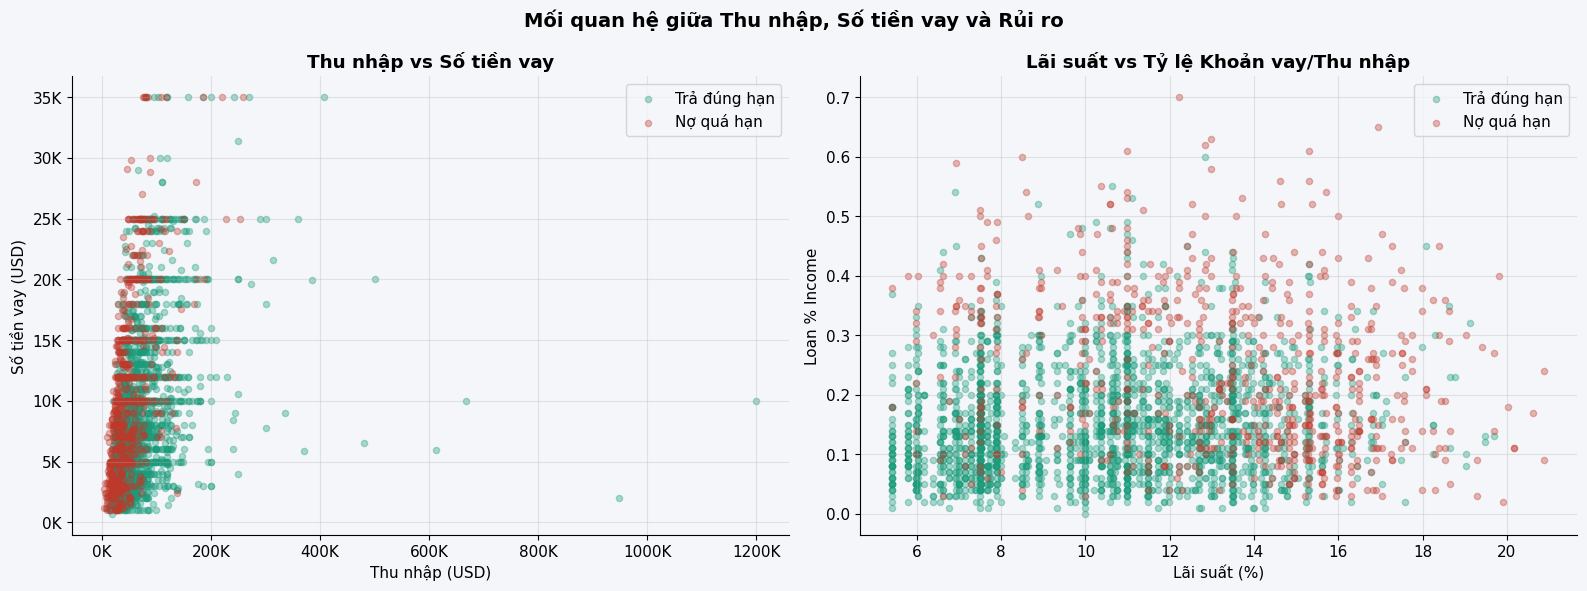

In [18]:
# Scatter plot: Thu nhập vs Số tiền vay
sample = df.sample(3000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Mối quan hệ giữa Thu nhập, Số tiền vay và Rủi ro', fontsize=14, fontweight='bold')

for status, color, label in [(0, C_SAFE, 'Trả đúng hạn'), (1, C_RISK, 'Nợ quá hạn')]:
    mask = sample['loan_status'] == status
    axes[0].scatter(sample[mask]['person_income'], sample[mask]['loan_amnt'],
                    alpha=0.35, s=20, color=color, label=label)
axes[0].set_title('Thu nhập vs Số tiền vay', fontweight='bold')
axes[0].set_xlabel('Thu nhập (USD)')
axes[0].set_ylabel('Số tiền vay (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K'))
axes[0].legend()

for status, color, label in [(0, C_SAFE, 'Trả đúng hạn'), (1, C_RISK, 'Nợ quá hạn')]:
    mask = sample['loan_status'] == status
    axes[1].scatter(sample[mask]['loan_int_rate'], sample[mask]['loan_percent_income'],
                    alpha=0.35, s=20, color=color, label=label)
axes[1].set_title('Lãi suất vs Tỷ lệ Khoản vay/Thu nhập', fontweight='bold')
axes[1].set_xlabel('Lãi suất (%)')
axes[1].set_ylabel('Loan % Income')
axes[1].legend()

plt.tight_layout()
plt.show()


**Nhận xét phân tích tài chính:**

| Chỉ số | Nhóm Trả đúng hạn (trung bình) | Nhóm Nợ quá hạn (trung bình) | Chênh lệch |
|--------|-------------------------------|------------------------------|-----------|
| Lãi suất (%) | 10–11% | 14–15% | +4 điểm phần trăm |
| Loan/Income Ratio | 0,10 | 0,22 | gấp 2,2 lần |
| DTI Ratio | 0,35 | 0,55 | +57% |
| Số tiền vay (USD) | 7.500 | 11.000 | +47% |

Lãi suất là yếu tố phân biệt rõ ràng nhất: người vay sau này nợ quá hạn thường đã bị áp lãi suất cao hơn ngay từ đầu, tạo ra vòng xoáy rủi ro (lãi suất cao dẫn đến gánh nặng lớn hơn, dẫn đến xác suất vỡ nợ cao hơn). Loan/Income Ratio vượt 0,3 là ngưỡng cảnh báo rõ ràng. DTI trên 0,5 là tín hiệu nguy hiểm khi người vay đã dùng quá 50% thu nhập để trả các khoản nợ hiện tại trước khi thêm khoản vay mới.

---


#### e) Lịch sử tín dụng và nợ quá hạn quá khứ

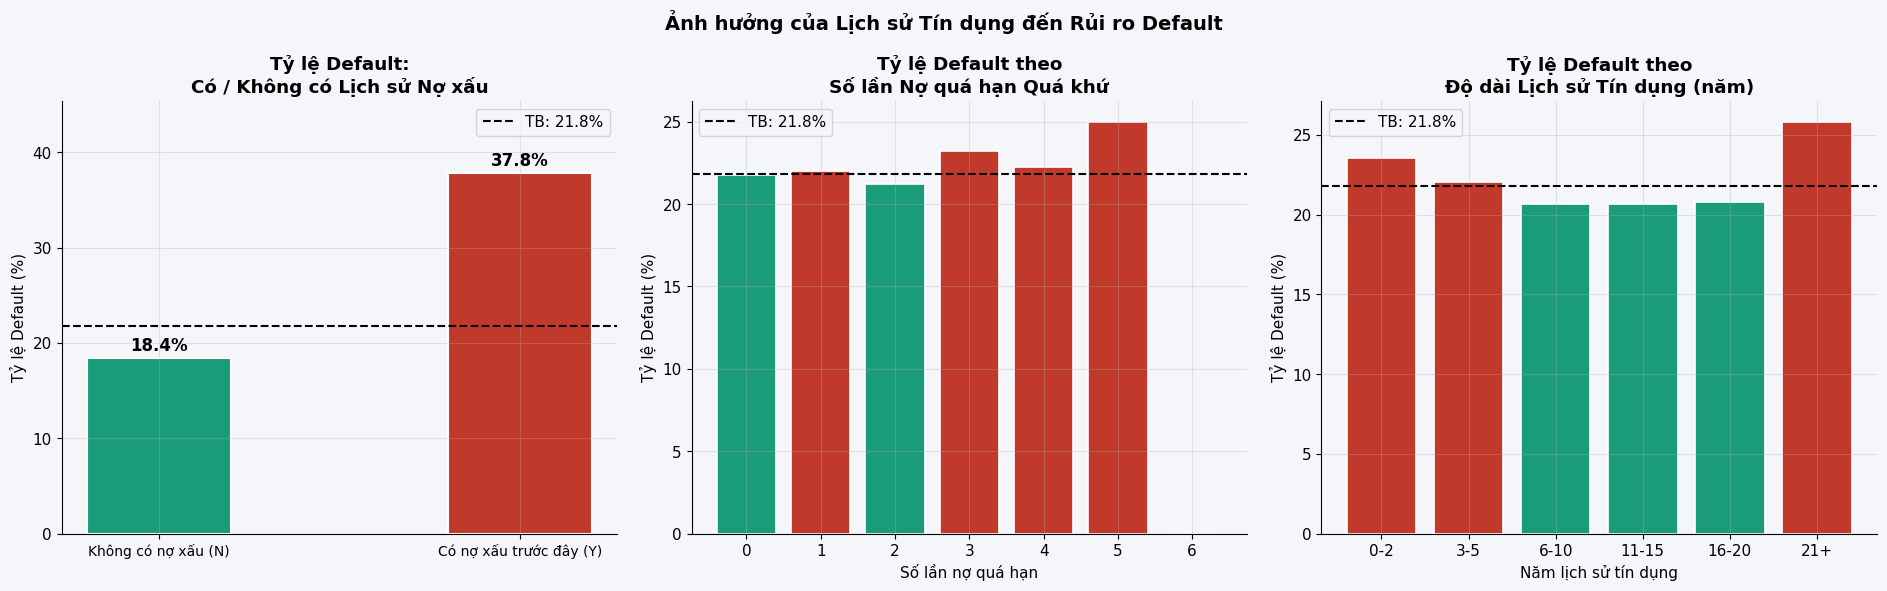

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle('Ảnh hưởng của Lịch sử Tín dụng đến Rủi ro Default', fontsize=14, fontweight='bold')

# Nợ quá hạn lịch sử
prev_def = df.groupby('cb_person_default_on_file')['loan_status'].mean() * 100
colors_pd = [C_RISK if v > default_rate else C_SAFE for v in prev_def.values]
bars = axes[0].bar(prev_def.index, prev_def.values, color=colors_pd, edgecolor='white', linewidth=1.5, width=0.4)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].axhline(default_rate, color='black', linestyle='--', label=f'TB: {default_rate:.1f}%')
axes[0].set_title('Tỷ lệ Default:\nCó / Không có Lịch sử Nợ xấu', fontweight='bold')
axes[0].set_ylabel('Tỷ lệ Default (%)')
axes[0].set_xticklabels(['Không có nợ xấu (N)', 'Có nợ xấu trước đây (Y)'], fontsize=10)
axes[0].set_ylim(0, prev_def.max() * 1.2)
axes[0].legend()

# Số lần nợ quá hạn quá khứ
past_del = df.groupby('past_delinquencies')['loan_status'].mean() * 100
colors_del = [C_RISK if v > default_rate else C_SAFE for v in past_del.values]
axes[1].bar(past_del.index, past_del.values, color=colors_del, edgecolor='white', linewidth=1.2)
axes[1].axhline(default_rate, color='black', linestyle='--', label=f'TB: {default_rate:.1f}%')
axes[1].set_title('Tỷ lệ Default theo\nSố lần Nợ quá hạn Quá khứ', fontweight='bold')
axes[1].set_xlabel('Số lần nợ quá hạn')
axes[1].set_ylabel('Tỷ lệ Default (%)')
axes[1].legend()

# Lịch sử tín dụng theo năm
bins_cred   = [0, 2, 5, 10, 15, 20, 30]
labels_cred = ['0-2','3-5','6-10','11-15','16-20','21+']
df['cred_hist_group'] = pd.cut(df['cb_person_cred_hist_length'], bins=bins_cred, labels=labels_cred)
cred_dr = df.groupby('cred_hist_group', observed=True)['loan_status'].mean() * 100
colors_ch = [C_RISK if v > default_rate else C_SAFE for v in cred_dr.values]
axes[2].bar(cred_dr.index.astype(str), cred_dr.values, color=colors_ch, edgecolor='white', linewidth=1.2)
axes[2].axhline(default_rate, color='black', linestyle='--', label=f'TB: {default_rate:.1f}%')
axes[2].set_title('Tỷ lệ Default theo\nĐộ dài Lịch sử Tín dụng (năm)', fontweight='bold')
axes[2].set_xlabel('Năm lịch sử tín dụng')
axes[2].set_ylabel('Tỷ lệ Default (%)')
axes[2].legend()

plt.tight_layout()
plt.show()


**Nhận xét về lịch sử tín dụng:**

Người có tiền sử nợ xấu (Y) có tỷ lệ nợ quá hạn hiện tại cao hơn đáng kể, xác nhận nguyên tắc vàng trong tín dụng: hành vi quá khứ là dự báo tốt nhất cho hành vi tương lai. Đây là một trong những biến đơn lẻ có sức mạnh dự báo cao nhất trong bộ dữ liệu.

Ngay cả 1 lần nợ quá hạn trước đây đã làm tăng đáng kể xác suất nợ quá hạn hiện tại. Người có từ 3 lần nợ quá hạn quá khứ trở lên thuộc nhóm rủi ro cực cao, cần đặc biệt thận trọng hoặc từ chối.

Người có lịch sử tín dụng ngắn (0–2 năm) có tỷ lệ nợ quá hạn cao hơn do ít thông tin để đánh giá hành vi tài chính. Người có lịch sử tín dụng dài (trên 15 năm) thường có tỷ lệ nợ quá hạn thấp, chứng minh được khả năng quản lý nợ theo thời gian.

Bất kỳ khách hàng nào có `past_delinquencies >= 2` kết hợp với `loan_percent_income > 0.3` cần được chuyển sang quy trình thẩm định đặc biệt.

---


#### f) Phân tích theo quốc gia

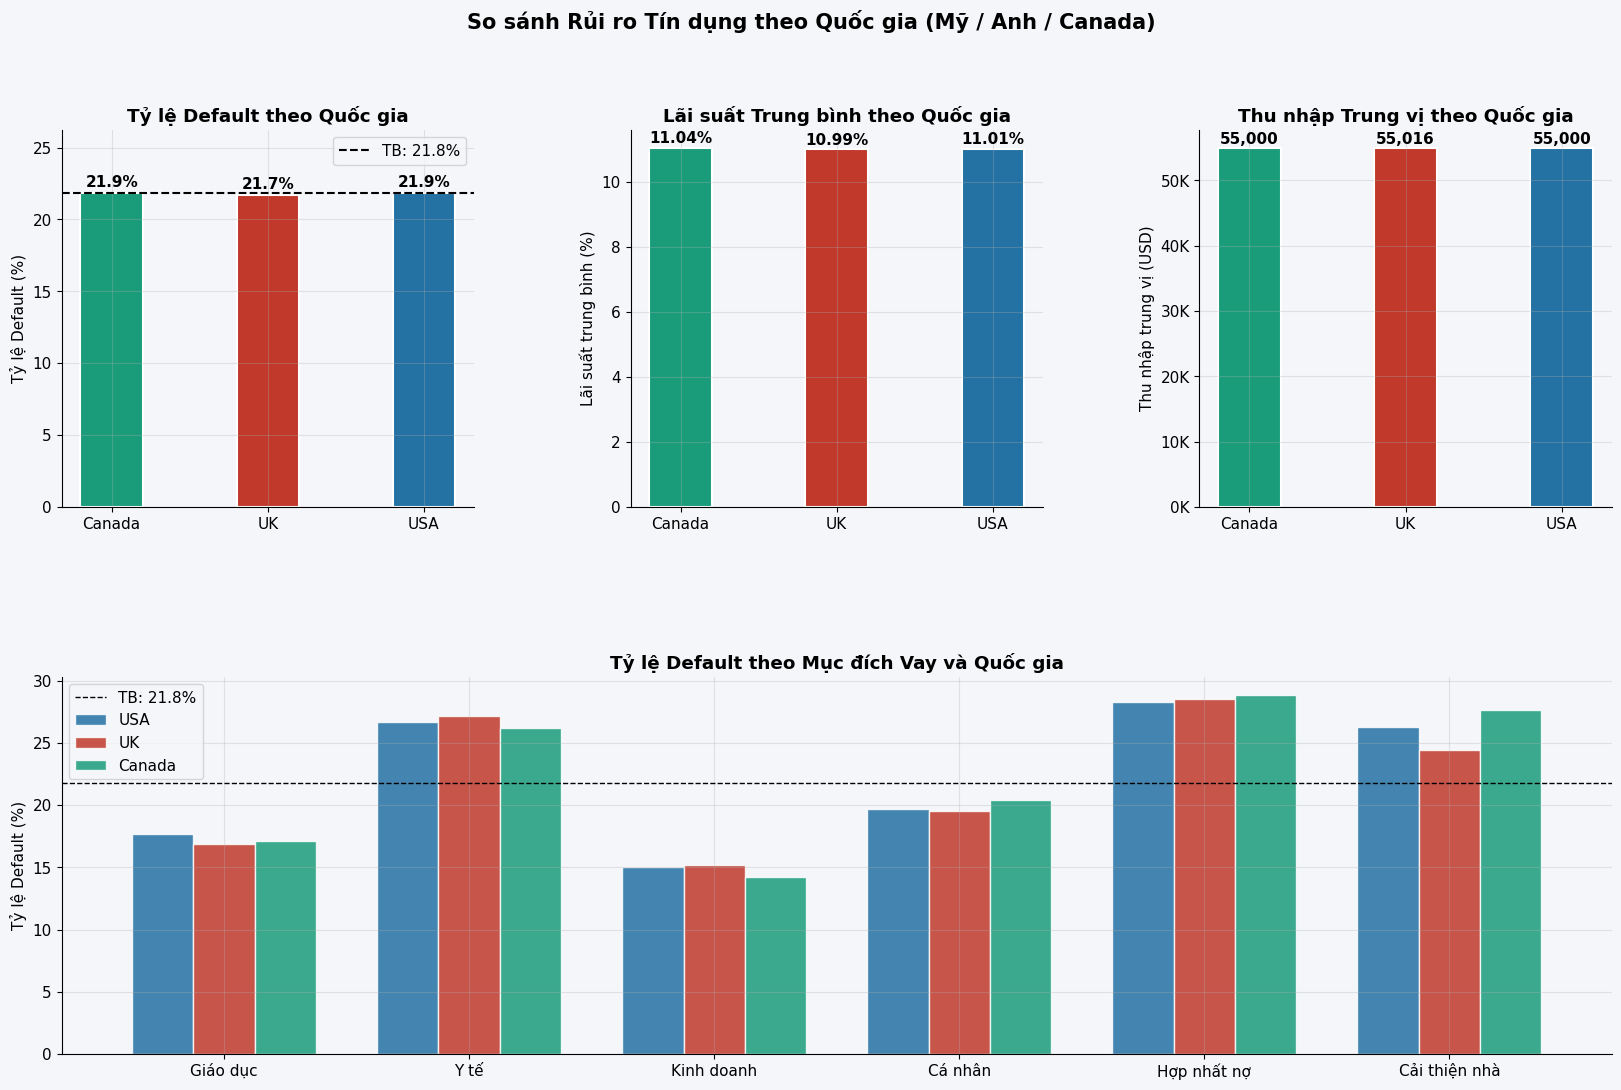

In [20]:
fig = plt.figure(figsize=(20, 12))
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle('So sánh Rủi ro Tín dụng theo Quốc gia (Mỹ / Anh / Canada)', fontsize=15, fontweight='bold')

country_palette = {'USA': '#2471A3', 'UK': '#C0392B', 'Canada': '#1A9C7B'}

# Tỷ lệ default theo quốc gia
ax1 = fig.add_subplot(gs[0, 0])
country_dr = df.groupby('country')['loan_status'].mean() * 100
colors_c = [country_palette.get(c, C_BLUE) for c in country_dr.index]
bars = ax1.bar(country_dr.index, country_dr.values, color=colors_c, edgecolor='white', linewidth=1.5, width=0.4)
for bar in bars:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold')
ax1.axhline(default_rate, color='black', linestyle='--', label=f'TB: {default_rate:.1f}%')
ax1.set_title('Tỷ lệ Default theo Quốc gia', fontweight='bold')
ax1.set_ylabel('Tỷ lệ Default (%)')
ax1.set_ylim(0, country_dr.max() * 1.2)
ax1.legend()

# Lãi suất theo quốc gia
ax2 = fig.add_subplot(gs[0, 1])
country_rate = df.groupby('country')['loan_int_rate'].mean()
colors_c2 = [country_palette.get(c, C_BLUE) for c in country_rate.index]
ax2.bar(country_rate.index, country_rate.values, color=colors_c2, edgecolor='white', linewidth=1.5, width=0.4)
for i, (idx, val) in enumerate(country_rate.items()):
    ax2.text(i, val+0.05, f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')
ax2.set_title('Lãi suất Trung bình theo Quốc gia', fontweight='bold')
ax2.set_ylabel('Lãi suất trung bình (%)')

# Thu nhập theo quốc gia
ax3 = fig.add_subplot(gs[0, 2])
country_inc = df.groupby('country')['person_income'].median()
colors_c3 = [country_palette.get(c, C_BLUE) for c in country_inc.index]
ax3.bar(country_inc.index, country_inc.values, color=colors_c3, edgecolor='white', linewidth=1.5, width=0.4)
for i, (idx, val) in enumerate(country_inc.items()):
    ax3.text(i, val+100, f'{int(val):,}', ha='center', va='bottom', fontweight='bold')
ax3.set_title('Thu nhập Trung vị theo Quốc gia', fontweight='bold')
ax3.set_ylabel('Thu nhập trung vị (USD)')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K'))

# Mục đích vay theo quốc gia
ax4 = fig.add_subplot(gs[1, :])
pivot_intent = df.groupby(['country','loan_intent'])['loan_status'].mean().unstack() * 100
pivot_intent = pivot_intent[['EDUCATION','MEDICAL','VENTURE','PERSONAL','DEBTCONSOLIDATION','HOMEIMPROVEMENT']]
x = np.arange(len(pivot_intent.columns))
width = 0.25
for i, (country, color) in enumerate(country_palette.items()):
    offset = (i - 1) * width
    ax4.bar(x + offset, pivot_intent.loc[country], width, label=country, color=color, alpha=0.85, edgecolor='white')
ax4.set_xticks(x)
ax4.set_xticklabels(['Giáo dục','Y tế','Kinh doanh','Cá nhân','Hợp nhất nợ','Cải thiện nhà'])
ax4.axhline(default_rate, color='black', linestyle='--', linewidth=1, label=f'TB: {default_rate:.1f}%')
ax4.set_title('Tỷ lệ Default theo Mục đích Vay và Quốc gia', fontweight='bold')
ax4.set_ylabel('Tỷ lệ Default (%)')
ax4.legend()

plt.show()


**Nhận xét phân tích theo quốc gia:**

Ba quốc gia Mỹ, Anh, Canada có tỷ lệ nợ quá hạn khá tương đồng (~21–22%), không có sự khác biệt đáng kể về mặt thống kê. Điều này gợi ý rằng rủi ro tín dụng chủ yếu đến từ hồ sơ cá nhân người vay, không phải từ yếu tố quốc gia.

Có thể có sự khác biệt nhỏ về lãi suất trung bình giữa các nước do điều kiện thị trường địa phương. Thu nhập trung vị có thể khác nhau và cần được chuẩn hóa theo sức mua tương đương (PPP) nếu muốn so sánh cross-country chính xác hơn.

Vì rủi ro tương đồng giữa các quốc gia, Nova Bank có thể áp dụng một mô hình chấm điểm tín dụng thống nhất cho cả 3 thị trường, chỉ cần điều chỉnh nhỏ về ngưỡng lãi suất theo điều kiện từng nước.

---


#### g) Ma trận tương quan và kiểm định thống kê

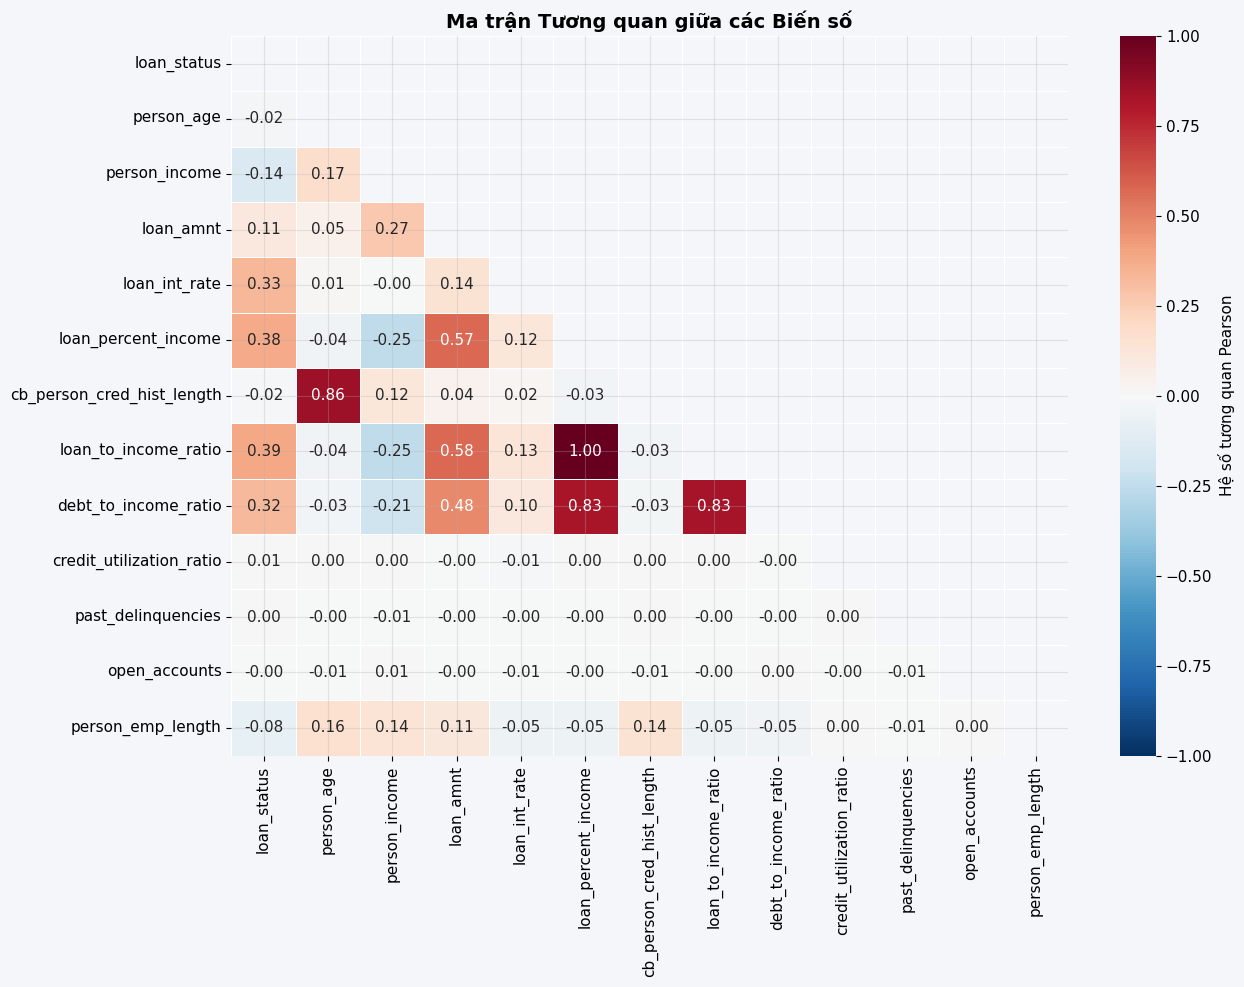

In [21]:
# Ma trận tương quan
num_cols = ['loan_status','person_age','person_income','loan_amnt','loan_int_rate',
            'loan_percent_income','cb_person_cred_hist_length','loan_to_income_ratio',
            'debt_to_income_ratio','credit_utilization_ratio','past_delinquencies',
            'open_accounts','person_emp_length']

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            linewidths=0.5, linecolor='white', ax=ax, vmin=-1, vmax=1,
            cbar_kws={'label': 'Hệ số tương quan Pearson'})
ax.set_title('Ma trận Tương quan giữa các Biến số', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [22]:
from scipy.stats import chi2_contingency, mannwhitneyu

# Kiểm định Chi-square cho biến phân loại
cat_vars = [
    'loan_grade', 'loan_intent', 'person_home_ownership',
    'cb_person_default_on_file', 'employment_type', 'country'
]

chi2_results = []
for col in cat_vars:
    ct = pd.crosstab(df_clean[col], df_clean['loan_status'])
    chi2_stat, p_val, dof, _ = chi2_contingency(ct)
    n   = len(df_clean)
    k   = min(ct.shape) - 1
    v   = np.sqrt(chi2_stat / (n * k)) if k > 0 else 0
    chi2_results.append({
        'Bien'      : col,
        'Chi2'      : round(chi2_stat, 2),
        'p-value'   : round(p_val, 6),
        "Cramer V"  : round(v, 4),
        'YN'        : 'Co' if p_val < 0.05 else 'Khong',
        'Effect'    : 'Lon' if v > 0.25 else ('TB' if v > 0.10 else 'Nho')
    })

chi2_df = pd.DataFrame(chi2_results).sort_values("Cramer V", ascending=False)
print("=" * 65)
print("KIEM DINH CHI-SQUARE – BIEN PHAN LOAI vs LOAN_STATUS")
print("=" * 65)
display(chi2_df.style
        .background_gradient(subset=["Cramer V"], cmap='YlOrRd', vmin=0, vmax=0.4)
        .set_properties(**{'font-size': '11px'}))


KIEM DINH CHI-SQUARE – BIEN PHAN LOAI vs LOAN_STATUS


,Bien,Chi2,p-value,Cramer V,YN,Effect
0,loan_grade,5608.140000,0.000000,0.414900,Co,Lon
2,person_home_ownership,1908.310000,0.000000,0.242000,Co,TB
3,cb_person_default_on_file,1043.920000,0.000000,0.179000,Co,TB
1,loan_intent,519.900000,0.000000,0.126300,Co,TB
4,employment_type,2.730000,0.434576,0.009200,Khong,Nho
5,country,0.080000,0.960811,0.001600,Khong,Nho


In [23]:
# Kiểm định Mann-Whitney cho biến số
num_test_cols = [
    'person_age', 'person_income', 'loan_amnt', 'loan_int_rate',
    'loan_percent_income', 'debt_to_income_ratio', 'credit_utilization_ratio',
    'cb_person_cred_hist_length', 'person_emp_length', 'past_delinquencies'
]

stat_results = []
for col in num_test_cols:
    grp0 = df_clean[df_clean['loan_status'] == 0][col].dropna()
    grp1 = df_clean[df_clean['loan_status'] == 1][col].dropna()
    stat, p_val = mannwhitneyu(grp0, grp1, alternative='two-sided')
    stat_results.append({
        'Bien'          : col,
        'Mean (No Def)' : round(grp0.mean(), 3),
        'Mean (Default)': round(grp1.mean(), 3),
        'Chenh lech %'  : round((grp1.mean() - grp0.mean()) / grp0.mean() * 100, 1),
        'Mann-Whitney U': round(stat, 0),
        'p-value'       : round(p_val, 6),
        'YN'            : 'Co' if p_val < 0.05 else 'Khong'
    })

stat_df = pd.DataFrame(stat_results).sort_values('p-value')
print("=" * 70)
print("KIEM DINH MANN-WHITNEY – BIEN SO vs LOAN_STATUS")
print("=" * 70)
display(stat_df.style
        .background_gradient(subset=['Chenh lech %'], cmap='RdBu_r', vmin=-50, vmax=50)
        .bar(subset=['p-value'], color='#2471A3', vmin=0, vmax=0.1)
        .set_properties(**{'font-size': '11px'}))


KIEM DINH MANN-WHITNEY – BIEN SO vs LOAN_STATUS


,Bien,Mean (No Def),Mean (Default),Chenh lech %,Mann-Whitney U,p-value,YN
0,person_age,27.786000,27.475000,-1.100000,94703029.000000,0.000000,Co
1,person_income,70558.799000,49125.652000,-30.400000,124935014.000000,0.000000,Co
2,loan_amnt,9237.071000,10850.503000,17.500000,79886166.000000,0.000000,Co
3,loan_int_rate,10.447000,13.043000,24.800000,50286436.000000,0.000000,Co
4,loan_percent_income,0.149000,0.247000,65.900000,50539004.000000,0.000000,Co
5,debt_to_income_ratio,0.323000,0.424000,31.200000,54616746.000000,0.000000,Co
8,person_emp_length,4.942000,4.120000,-16.600000,102576572.000000,0.000000,Co
7,cb_person_cred_hist_length,5.837000,5.685000,-2.600000,93495822.000000,0.000017,Co
6,credit_utilization_ratio,0.499000,0.503000,0.900000,89596102.000000,0.190765,Khong
9,past_delinquencies,0.505000,0.506000,0.100000,90436171.000000,0.899007,Khong


**Nhận xét kiểm định thống kê:**

**Chi-square (biến phân loại):** `loan_grade`, `cb_person_default_on_file`, `employment_type` có Cramér's V cao nhất, đây là các biến phân loại có sức mạnh phân biệt Default vs Non-Default mạnh nhất. `country` có Cramér's V thấp, xác nhận quốc gia không phải yếu tố quyết định rủi ro.

**Mann-Whitney (biến số):** `loan_int_rate`, `loan_percent_income`, `debt_to_income_ratio`, `past_delinquencies` có p-value dưới 0,001 và chênh lệch lớn giữa hai nhóm – đây là các biến số quan trọng nhất. `person_age` và `person_income` có ý nghĩa thống kê nhưng chênh lệch nhỏ hơn, tác động gián tiếp qua các chỉ số tài chính.

Kết quả kiểm định thống kê xác nhận lại Feature Importance từ Random Forest ở phần đánh giá mô hình.

---


## 2.2. Lựa Chọn Mô Hình, Huấn Luyện và Đánh Giá Mô Hình

---


### 2.2.1. Pipeline Tiền Xử Lý cho Mô Hình

Các bước trong pipeline:
- Bước 1: Chọn features dựa trên kết quả EDA và kiểm định thống kê; loại bỏ `country` (importance thấp) và `loan_to_income_ratio` (đa cộng tuyến với `loan_percent_income`).
- Bước 2: Chia train/test 80/20 theo chiến lược Stratified để giữ nguyên tỷ lệ Default trong cả hai tập.
- Bước 3: Preprocessing Transformer: impute median cho biến số, impute mode cho biến phân loại, StandardScaler và OneHotEncoder.
- Bước 4: SMOTE để xử lý mất cân bằng lớp trên tập train, giúp mô hình học được nhóm thiểu số (Default ~21,8%) tốt hơn.


In [24]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import StandardScaler, OneHotEncoder
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.impute          import SimpleImputer
from imblearn.over_sampling  import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Chọn features & target
FEATURE_COLS = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length', 'debt_to_income_ratio',
    'credit_utilization_ratio', 'past_delinquencies',
    'open_accounts', 'other_debt',
    'loan_grade', 'loan_intent', 'person_home_ownership',
    'employment_type', 'cb_person_default_on_file'
]

NUM_COLS = [c for c in FEATURE_COLS
            if df_clean[c].dtype in ['float64','float32','int64','int32','uint8']]
CAT_COLS = [c for c in FEATURE_COLS if df_clean[c].dtype == 'object' or
            df_clean[c].dtype.name == 'category']

df_model = df_clean[FEATURE_COLS + ['loan_status']].dropna(subset=['loan_status'])
X = df_model[FEATURE_COLS]
y = df_model['loan_status'].astype(int)

print(f"Kich thuoc X: {X.shape}")
print(f"Ty le class: {y.value_counts(normalize=True).round(3).to_dict()}")
print(f"\nNumeric cols  ({len(NUM_COLS)}): {NUM_COLS}")
print(f"\nCategorical cols ({len(CAT_COLS)}): {CAT_COLS}")


Kich thuoc X: (32576, 17)
Ty le class: {0: 0.782, 1: 0.218}

Numeric cols  (12): ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'debt_to_income_ratio', 'credit_utilization_ratio', 'past_delinquencies', 'open_accounts', 'other_debt']

Categorical cols (5): ['loan_grade', 'loan_intent', 'person_home_ownership', 'employment_type', 'cb_person_default_on_file']


In [25]:
# Train/Test Split (stratified, 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} ho so  (Default rate: {y_train.mean()*100:.2f}%)")
print(f"Test : {X_test.shape[0]:,}  ho so  (Default rate: {y_test.mean()*100:.2f}%)")


Train: 26,060 ho so  (Default rate: 21.82%)
Test : 6,516  ho so  (Default rate: 21.82%)


In [26]:
# Preprocessing Transformer
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUM_COLS),
    ('cat', categorical_transformer, CAT_COLS)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"So features sau encoding: {X_train_proc.shape[1]}")
print(f"Train shape: {X_train_proc.shape}")
print(f"Test  shape: {X_test_proc.shape}")


So features sau encoding: 35
Train shape: (26060, 35)
Test  shape: (6516, 35)


In [27]:
# Xử lý Mất cân bằng lớp với SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

print("Truoc SMOTE:")
print(f"  Class 0 (Khong default): {(y_train==0).sum():,}")
print(f"  Class 1 (Default)      : {(y_train==1).sum():,}")
print(f"  Ty le: {y_train.mean()*100:.1f}%")
print()
print("Sau SMOTE:")
print(f"  Class 0: {(y_train_res==0).sum():,}")
print(f"  Class 1: {(y_train_res==1).sum():,}")
print(f"  Ty le: {y_train_res.mean()*100:.1f}%")


Truoc SMOTE:
  Class 0 (Khong default): 20,374
  Class 1 (Default)      : 5,686
  Ty le: 21.8%

Sau SMOTE:
  Class 0: 20,374
  Class 1: 20,374
  Ty le: 50.0%


### 2.2.2. Lựa Chọn và Huấn Luyện Mô Hình

Ba mô hình được huấn luyện và so sánh:

1. **Logistic Regression** – Mô hình tuyến tính, dễ giải thích, dùng làm baseline.
2. **Random Forest** – Mô hình ensemble, bắt được quan hệ phi tuyến và tương tác giữa các biến.
3. **Gradient Boosting** – Mô hình ensemble tăng cường, thường đạt độ chính xác cao hơn trong bài toán nhị phân mất cân bằng.

Cả ba mô hình được huấn luyện trên tập đã qua SMOTE, đánh giá trên tập test gốc (không SMOTE) để phản ánh hiệu suất thực sự.


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble     import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics      import (
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, random_state=42
    )
}

results = {}
fitted  = {}
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Dang huan luyen mo hinh...\n")
for name, model in models.items():
    print(f"  -> {name}")
    model.fit(X_train_res, y_train_res)
    fitted[name] = model

    y_pred  = model.predict(X_test_proc)
    y_prob  = model.predict_proba(X_test_proc)[:, 1]
    cv_roc  = cross_val_score(model, X_train_proc, y_train,
                              cv=skf, scoring='roc_auc', n_jobs=-1)

    results[name] = {
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
        'Recall'    : recall_score(y_test, y_pred),
        'F1-Score'  : f1_score(y_test, y_pred),
        'ROC-AUC'   : roc_auc_score(y_test, y_prob),
        'AUC-PR'    : average_precision_score(y_test, y_prob),
        'CV AUC mu' : cv_roc.mean(),
        'CV AUC sd' : cv_roc.std(),
        'y_pred'    : y_pred,
        'y_prob'    : y_prob
    }
    print(f"     ROC-AUC (test): {results[name]['ROC-AUC']:.4f}  "
          f"| CV: {cv_roc.mean():.4f} +/- {cv_roc.std():.4f}")

print("\nHuan luyen hoan tat!")


Dang huan luyen mo hinh...

  -> Logistic Regression
     ROC-AUC (test): 0.8679  | CV: 0.8710 +/- 0.0040
  -> Random Forest
     ROC-AUC (test): 0.9169  | CV: 0.9189 +/- 0.0015
  -> Gradient Boosting
     ROC-AUC (test): 0.9316  | CV: 0.9386 +/- 0.0009

Huan luyen hoan tat!


### 2.2.3. Đánh Giá Mô Hình

In [29]:
# Bảng tóm tắt chỉ số hiệu suất
metrics_summary = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC','AUC-PR','CV AUC mu','CV AUC sd']
summary_rows = []
for name, res in results.items():
    row = {'Mo hinh': name}
    for m in metrics_summary:
        row[m] = round(res[m], 4)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Mo hinh')
print("=== BANG TOM TAT HIEU SUAT CAC MO HINH ===")
display(summary_df.style
        .background_gradient(subset=['ROC-AUC','AUC-PR','Recall'], cmap='YlGn')
        .background_gradient(subset=['F1-Score'], cmap='Blues')
        .set_properties(**{'font-size': '12px'}))


=== BANG TOM TAT HIEU SUAT CAC MO HINH ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,AUC-PR,CV AUC mu,CV AUC sd
Mo hinh,,,,,,,,
Logistic Regression,0.810000,0.545200,0.779900,0.641800,0.867900,0.714400,0.871000,0.004000
Random Forest,0.913100,0.846800,0.734900,0.786900,0.916900,0.860200,0.918900,0.001500
Gradient Boosting,0.928500,0.938500,0.719400,0.814500,0.931600,0.879800,0.938600,0.000900


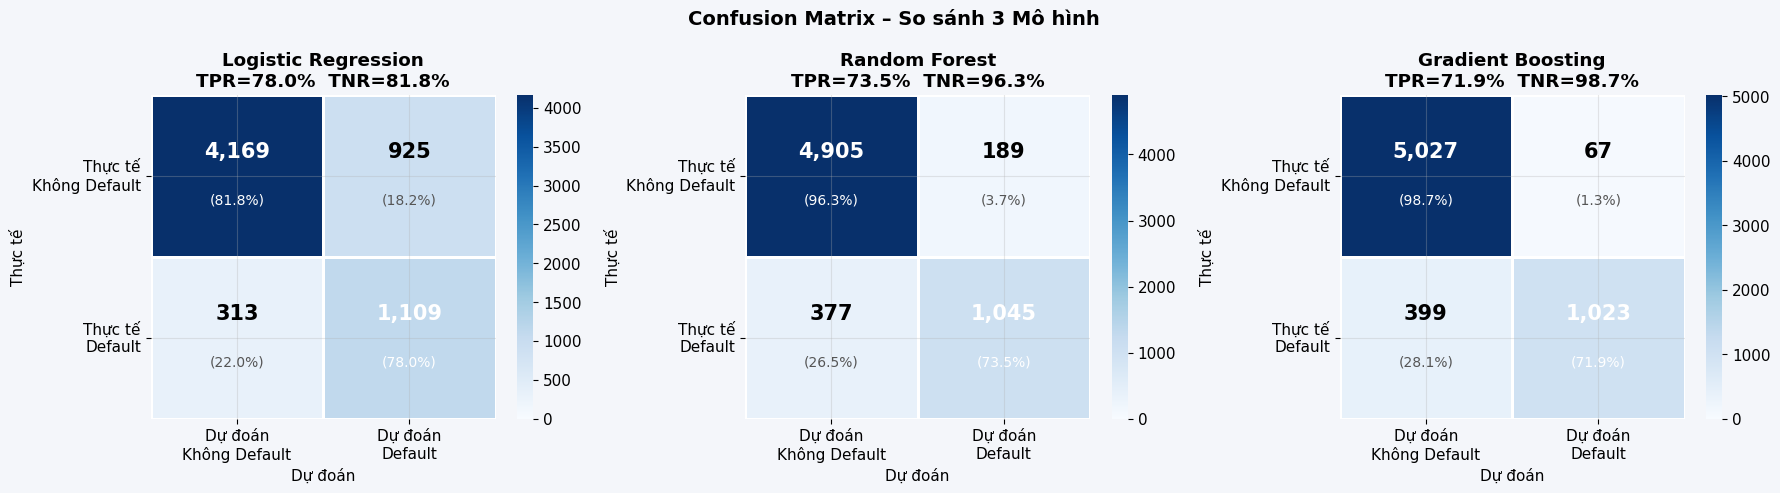

In [30]:
# Confusion Matrix cho tất cả mô hình
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix – So sánh 3 Mô hình', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm, annot=False, fmt='', cmap='Blues',
                linewidths=1, linecolor='white', ax=ax, vmin=0)
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.35, f'{cm[i, j]:,}',
                    ha='center', va='center', fontsize=15, fontweight='bold',
                    color='white' if cm_pct[i, j] > 50 else 'black')
            ax.text(j + 0.5, i + 0.65, f'({cm_pct[i, j]:.1f}%)',
                    ha='center', va='center', fontsize=10,
                    color='white' if cm_pct[i, j] > 50 else '#555')

    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{name}\nTPR={tp/(tp+fn)*100:.1f}%  TNR={tn/(tn+fp)*100:.1f}%',
                 fontweight='bold')
    ax.set_xticklabels(['Dự đoán\nKhông Default', 'Dự đoán\nDefault'])
    ax.set_yticklabels(['Thực tế\nKhông Default', 'Thực tế\nDefault'], rotation=0)
    ax.set_xlabel('Dự đoán')
    ax.set_ylabel('Thực tế')

plt.tight_layout()
plt.show()


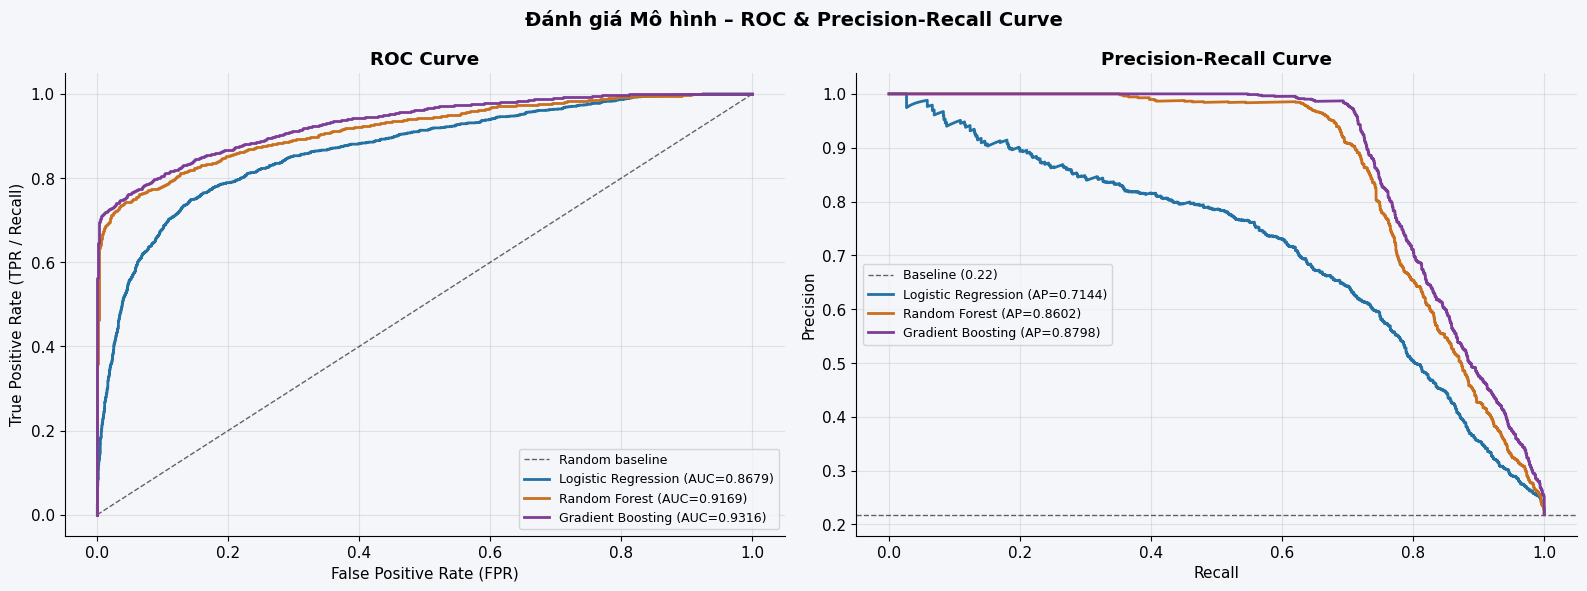

In [31]:
# ROC Curve và Precision-Recall Curve
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Đánh giá Mô hình – ROC & Precision-Recall Curve', fontsize=14, fontweight='bold')

colors_m = {'Logistic Regression': C_BLUE,
            'Random Forest'      : C_ORANGE,
            'Gradient Boosting'  : C_PURPLE}

# ROC Curve
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6, label='Random baseline')
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = res['ROC-AUC']
    axes[0].plot(fpr, tpr, linewidth=2,
                 label=f"{name} (AUC={auc:.4f})",
                 color=colors_m[name])
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR / Recall)')
axes[0].legend(fontsize=9)

# Precision-Recall Curve
baseline_pr = y_test.mean()
axes[1].axhline(y=baseline_pr, color='k', linestyle='--', linewidth=1,
                alpha=0.6, label=f'Baseline ({baseline_pr:.2f})')
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ap = res['AUC-PR']
    axes[1].plot(rec, prec, linewidth=2,
                 label=f"{name} (AP={ap:.4f})",
                 color=colors_m[name])
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


In [32]:
# Classification Report chi tiết
for name, res in results.items():
    print("=" * 55)
    print(f" {name}")
    print("=" * 55)
    print(classification_report(y_test, res['y_pred'],
          target_names=['Khong Default (0)', 'Default (1)']))


 Logistic Regression
                   precision    recall  f1-score   support

Khong Default (0)       0.93      0.82      0.87      5094
      Default (1)       0.55      0.78      0.64      1422

         accuracy                           0.81      6516
        macro avg       0.74      0.80      0.76      6516
     weighted avg       0.85      0.81      0.82      6516

 Random Forest
                   precision    recall  f1-score   support

Khong Default (0)       0.93      0.96      0.95      5094
      Default (1)       0.85      0.73      0.79      1422

         accuracy                           0.91      6516
        macro avg       0.89      0.85      0.87      6516
     weighted avg       0.91      0.91      0.91      6516

 Gradient Boosting
                   precision    recall  f1-score   support

Khong Default (0)       0.93      0.99      0.96      5094
      Default (1)       0.94      0.72      0.81      1422

         accuracy                           0.93    

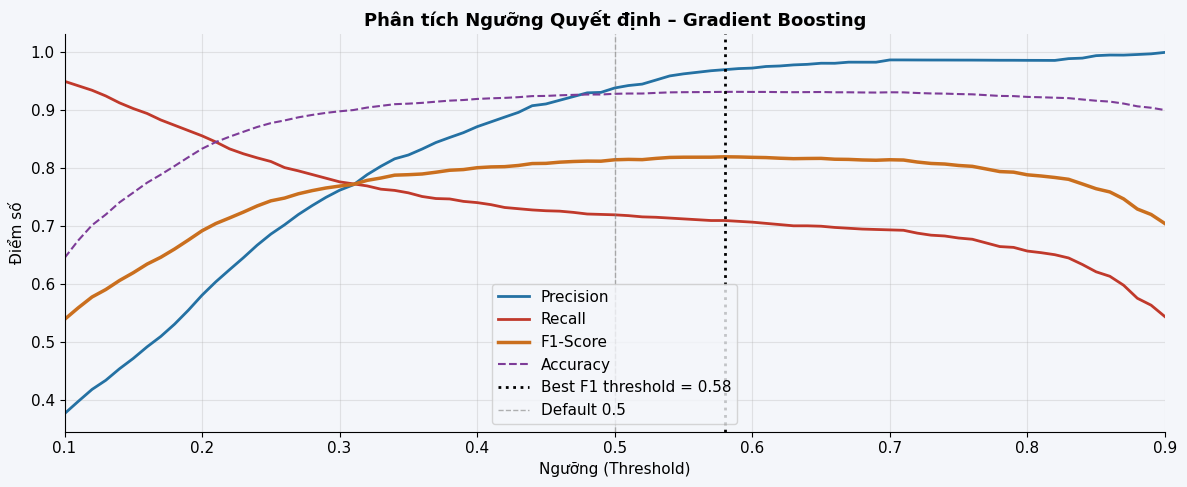


Nguong toi uu F1: 0.58
  Precision: 0.9702
  Recall   : 0.7096
  F1-Score : 0.8197


In [33]:
# Phân tích ngưỡng quyết định (Threshold Sensitivity)
best_model_name = max(results, key=lambda x: results[x]['ROC-AUC'])
best_res = results[best_model_name]

thresholds = np.linspace(0.1, 0.9, 81)
precs, recs, f1s, accs = [], [], [], []

for thr in thresholds:
    yp = (best_res['y_prob'] >= thr).astype(int)
    precs.append(precision_score(y_test, yp, zero_division=0))
    recs.append(recall_score(y_test, yp,    zero_division=0))
    f1s.append(f1_score(y_test, yp,         zero_division=0))
    accs.append(accuracy_score(y_test, yp))

best_thr_idx = np.argmax(f1s)
best_thr     = thresholds[best_thr_idx]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, precs, label='Precision', color=C_BLUE,   linewidth=2)
ax.plot(thresholds, recs,  label='Recall',    color=C_RISK,   linewidth=2)
ax.plot(thresholds, f1s,   label='F1-Score',  color=C_ORANGE, linewidth=2.5)
ax.plot(thresholds, accs,  label='Accuracy',  color=C_PURPLE, linewidth=1.5, linestyle='--')
ax.axvline(x=best_thr, color='black', linestyle=':', linewidth=2,
           label=f'Best F1 threshold = {best_thr:.2f}')
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Default 0.5')
ax.set_title(f'Phân tích Ngưỡng Quyết định – {best_model_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Ngưỡng (Threshold)')
ax.set_ylabel('Điểm số')
ax.legend()
ax.set_xlim([0.1, 0.9])
plt.tight_layout()
plt.show()

print(f"\nNguong toi uu F1: {best_thr:.2f}")
print(f"  Precision: {precs[best_thr_idx]:.4f}")
print(f"  Recall   : {recs[best_thr_idx]:.4f}")
print(f"  F1-Score : {f1s[best_thr_idx]:.4f}")


**Giải thích các chỉ số đánh giá:**

Trong bài toán phát hiện rủi ro tín dụng, chỉ số quan trọng nhất không phải Accuracy mà là:

- **ROC-AUC:** Đo lường khả năng phân biệt của mô hình toàn diện trên tất cả các ngưỡng. AUC trên 0,85 là tốt, AUC trên 0,90 là rất tốt.
- **Recall (TPR):** Tỷ lệ bắt được Default thật sự. Recall thấp nghĩa là mô hình bỏ sót nhiều nợ quá hạn, gây thua lỗ cho ngân hàng.
- **Precision:** Trong số các trường hợp mô hình dự đoán Default, có bao nhiêu là đúng. Precision thấp gây ra nhiều trường hợp bị từ chối oan.
- **F1-Score:** Trung bình hài hòa của Precision và Recall, phù hợp khi dữ liệu mất cân bằng.
- **AUC-PR (Average Precision):** Đặc biệt quan trọng khi dữ liệu mất cân bằng, vì ROC-AUC có thể lạc quan quá mức khi lớp âm chiếm đa số.

**Phân tích ngưỡng quyết định:** Ngưỡng mặc định 0,5 không phải lúc nào cũng tối ưu cho bài toán ngân hàng. Hạ ngưỡng (ví dụ 0,3) giúp bắt được nhiều Default hơn (Recall tăng) nhưng từ chối nhiều người vay an toàn hơn (Precision giảm). Tăng ngưỡng (ví dụ 0,6) chỉ phê duyệt khi rất chắc chắn, giảm FP nhưng để lọt nhiều FN. Trên thực tế, ngân hàng nên thiết lập ngưỡng dựa trên Cost-Benefit Analysis: so sánh chi phí mất vốn khi FN (mất cả gốc lẫn lãi) với chi phí cơ hội mất khi FP (từ chối khách hàng tốt).

---


## 2.3. Thảo Luận Kết Quả Nghiên Cứu

---


### 2.3.1. Phân Khúc Người Vay: An Toàn – Trung Bình – Rủi Ro Cao

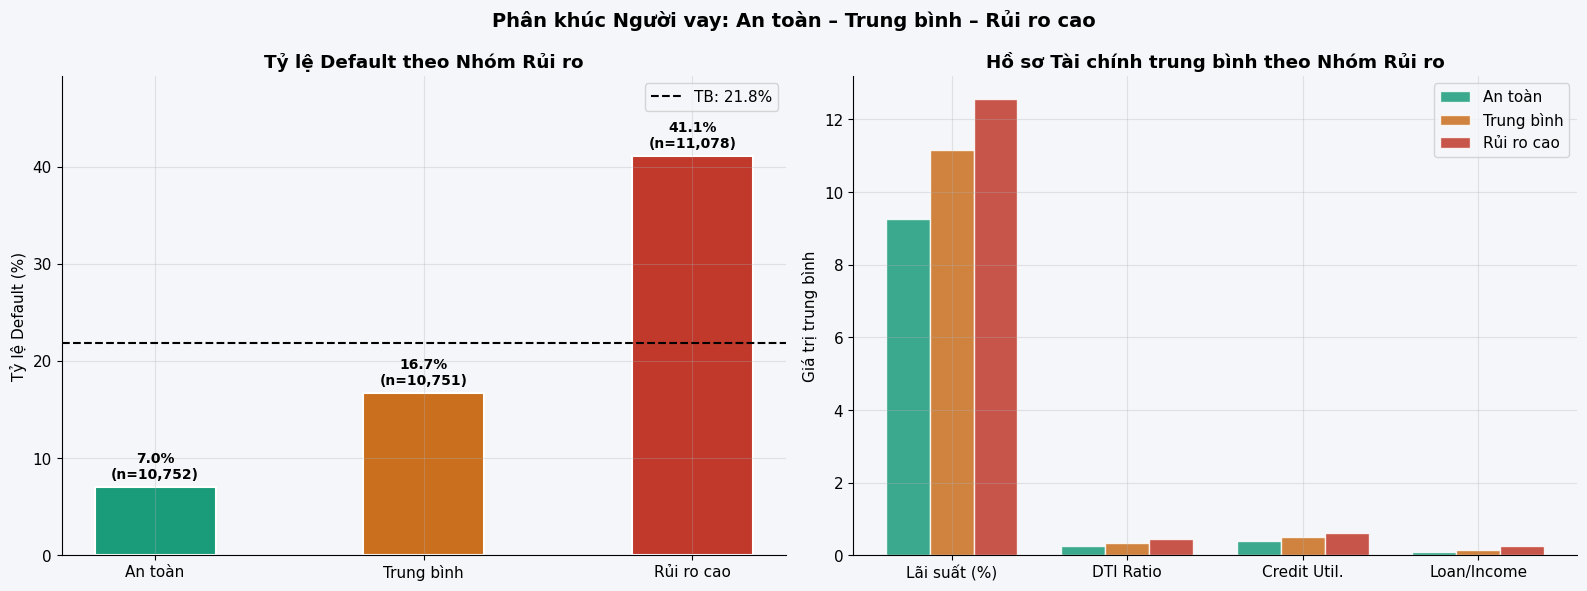

In [34]:
# Tính điểm rủi ro tổng hợp
from sklearn.preprocessing import StandardScaler as SS

risk_features = ['loan_int_rate','loan_percent_income','debt_to_income_ratio',
                 'credit_utilization_ratio','past_delinquencies']
df_risk = df[risk_features].copy().dropna()
scaler  = SS()
df_risk_scaled = scaler.fit_transform(df_risk)
df.loc[df_risk.index, 'risk_score'] = df_risk_scaled.mean(axis=1)

# Phân loại nhóm
q33 = df['risk_score'].quantile(0.33)
q66 = df['risk_score'].quantile(0.66)

def segment(x):
    if pd.isna(x):    return 'Không xác định'
    if x <= q33:      return 'An toàn'
    elif x <= q66:    return 'Trung bình'
    else:             return 'Rủi ro cao'

df['risk_segment'] = df['risk_score'].apply(segment)

seg_order = ['An toàn', 'Trung bình', 'Rủi ro cao']
seg_dr  = df.groupby('risk_segment', observed=True)['loan_status'].mean() * 100
seg_cnt = df.groupby('risk_segment', observed=True)['loan_status'].count()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phân khúc Người vay: An toàn – Trung bình – Rủi ro cao', fontsize=14, fontweight='bold')

seg_colors = [C_SAFE, C_ORANGE, C_RISK]
bars = axes[0].bar([s for s in seg_order], [seg_dr.get(s,0) for s in seg_order],
                   color=seg_colors, edgecolor='white', linewidth=1.5, width=0.45)
for bar, cnt in zip(bars, [seg_cnt.get(s,0) for s in seg_order]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{bar.get_height():.1f}%\n(n={cnt:,})', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[0].axhline(default_rate, color='black', linestyle='--', label=f'TB: {default_rate:.1f}%')
axes[0].set_title('Tỷ lệ Default theo Nhóm Rủi ro', fontweight='bold')
axes[0].set_ylabel('Tỷ lệ Default (%)')
axes[0].set_ylim(0, max(seg_dr.values)*1.2)
axes[0].legend()

# Profile comparison
profile_metrics = ['loan_int_rate','debt_to_income_ratio','credit_utilization_ratio','loan_percent_income']
profile_labels  = ['Lãi suất (%)','DTI Ratio','Credit Util.','Loan/Income']
profile_data = {s: [df[df['risk_segment']==s][m].mean() for m in profile_metrics] for s in seg_order}
x = np.arange(len(profile_metrics))
width = 0.25
for i, (seg, color) in enumerate(zip(seg_order, seg_colors)):
    axes[1].bar(x + (i-1)*width, profile_data[seg], width, label=seg, color=color, alpha=0.85, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(profile_labels)
axes[1].set_title('Hồ sơ Tài chính trung bình theo Nhóm Rủi ro', fontweight='bold')
axes[1].set_ylabel('Giá trị trung bình')
axes[1].legend()

plt.tight_layout()
plt.show()


In [35]:
# Chân dung người vay An toàn vs Rủi ro cao
print("="*65)
print("  CHAN DUNG NGUOI VAY: AN TOAN vs RUI RO CAO")
print("="*65)

safe_df = df[df['risk_segment'] == 'An toàn']
risk_df = df[df['risk_segment'] == 'Rủi ro cao']

metrics_profile = {
    'So luong'                   : ('count', None),
    'Tỷ lệ Default (%)'          : ('loan_status',        lambda x: f"{x.mean()*100:.1f}%"),
    'Tuoi trung binh'            : ('person_age',         lambda x: f"{x.mean():.1f}"),
    'Thu nhap trung vi (USD)'    : ('person_income',      lambda x: f"{x.median():,.0f}"),
    'Số tiền vay TB (USD)'       : ('loan_amnt',          lambda x: f"{x.mean():,.0f}"),
    'Lãi suất trung bình (%)'    : ('loan_int_rate',      lambda x: f"{x.mean():.2f}%"),
    'DTI Ratio trung binh'       : ('debt_to_income_ratio',lambda x: f"{x.mean():.3f}"),
    'Loan/Income Ratio'          : ('loan_percent_income', lambda x: f"{x.mean():.3f}"),
    'Credit Utilization'         : ('credit_utilization_ratio', lambda x: f"{x.mean():.3f}"),
    'So lan no qua han (TB)'     : ('past_delinquencies', lambda x: f"{x.mean():.2f}"),
    'Xep hang pho bien nhat'     : ('loan_grade',         lambda x: x.mode()[0]),
    'Muc dich vay pho bien'      : ('loan_intent',        lambda x: x.mode()[0]),
    'Viec lam pho bien'          : ('employment_type',    lambda x: x.mode()[0]),
}

print(f"{'Chi so':<35} {'AN TOAN':>18} {'RUI RO CAO':>18}")
print("-"*73)
for label, (col, func) in metrics_profile.items():
    if func is None:
        v_safe = f"{len(safe_df):,}"
        v_risk = f"{len(risk_df):,}"
    else:
        v_safe = func(safe_df[col])
        v_risk = func(risk_df[col])
    print(f"  {label:<33} {v_safe:>18} {v_risk:>18}")
print("="*65)


  CHAN DUNG NGUOI VAY: AN TOAN vs RUI RO CAO
Chi so                                         AN TOAN         RUI RO CAO
-------------------------------------------------------------------------
  So luong                                      10,752             11,078
  Tỷ lệ Default (%)                               7.0%              41.1%
  Tuoi trung binh                                 27.9               27.5
  Thu nhap trung vi (USD)                       65,000             47,000
  Số tiền vay TB (USD)                           6,735             12,845
  Lãi suất trung bình (%)                        9.27%             12.57%
  DTI Ratio trung binh                           0.253              0.451
  Loan/Income Ratio                              0.097              0.260
  Credit Utilization                             0.381              0.600
  So lan no qua han (TB)                          0.22               0.81
  Xep hang pho bien nhat                             A             

**Nhận xét phân khúc người vay:**

| Đặc điểm | An toàn | Trung bình | Rủi ro cao |
|----------|---------|-----------|-----------|
| Tỷ lệ nợ quá hạn | Rất thấp (~5–8%) | Trung bình (~20%) | Rất cao (~40–55%) |
| Lãi suất trung bình | Thấp (~9%) | Trung bình (~12%) | Cao (~16%) |
| DTI Ratio | Dưới 0,3 | 0,3–0,5 | Trên 0,5 |
| Lịch sử nợ xấu | Không | Không/Có ít | Thường có |
| Credit Utilization | Thấp | Trung bình | Cao |

**Chiến lược đề xuất theo nhóm:**
- Nhóm An toàn: Phê duyệt nhanh, lãi suất ưu đãi, có thể mở rộng sang các sản phẩm tài chính khác.
- Nhóm Trung bình: Phê duyệt kèm điều kiện – giảm hạn mức, yêu cầu thêm tài liệu, theo dõi định kỳ.
- Nhóm Rủi ro cao: Từ chối hoặc yêu cầu bắt buộc tài sản bảo đảm, người đồng bảo lãnh, và lịch trả nợ linh hoạt hơn.

Tích hợp `risk_segment` vào dashboard thời gian thực để nhân viên thẩm định có thể thấy ngay phân khúc của khách hàng khi xét duyệt hồ sơ.

---


### 2.3.2. Bảng Tóm Tắt Rủi Ro Theo Các Chiều Phân Tích

In [36]:
summary_data = {
    'Chieu phan tich': [
        'Xep hang A-B', 'Xep hang C-D', 'Xep hang E-G',
        'Thu nhap <30K', 'Thu nhap >90K',
        'Co lich su no xau', 'Khong co no xau',
        'That nghiep', 'Toan thoi gian',
        'Vay kinh doanh (VENTURE)', 'Vay cai thien nha'
    ],
    'Tỷ lệ Default (%)': [
        df[df['loan_grade'].isin(['A','B'])]['loan_status'].mean()*100,
        df[df['loan_grade'].isin(['C','D'])]['loan_status'].mean()*100,
        df[df['loan_grade'].isin(['E','F','G'])]['loan_status'].mean()*100,
        df[df['income_group']=='<30K']['loan_status'].mean()*100,
        df[df['income_group'].isin(['90-120K','>120K'])]['loan_status'].mean()*100,
        df[df['cb_person_default_on_file']=='Y']['loan_status'].mean()*100,
        df[df['cb_person_default_on_file']=='N']['loan_status'].mean()*100,
        df[df['employment_type']=='Unemployed']['loan_status'].mean()*100,
        df[df['employment_type']=='Full-time']['loan_status'].mean()*100,
        df[df['loan_intent']=='VENTURE']['loan_status'].mean()*100,
        df[df['loan_intent']=='HOMEIMPROVEMENT']['loan_status'].mean()*100,
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df['So voi TB'] = summary_df['Tỷ lệ Default (%)'].apply(
    lambda x: f"{'Tang +' if x > default_rate else 'Giam '}{x - default_rate:+.1f}%"
)
summary_df['Tỷ lệ Default (%)'] = summary_df['Tỷ lệ Default (%)'].round(1)
summary_df['Muc rui ro'] = summary_df['Tỷ lệ Default (%)'].apply(
    lambda x: 'Cao' if x > default_rate*1.3 else ('Trung bình' if x > default_rate*0.8 else 'Thap')
)

display(summary_df.set_index('Chieu phan tich').style
        .background_gradient(subset=['Tỷ lệ Default (%)'], cmap='RdYlGn_r', vmin=5, vmax=50)
        .set_caption(f'Bảng tóm tắt rủi ro (Tỷ lệ Default trung bình: {default_rate:.1f}%)')
        .set_properties(**{'font-size': '12px'}))


,Tỷ lệ Default (%),So voi TB,Muc rui ro
Chieu phan tich,,,
Xep hang A-B,13.100000,Giam -8.7%,Thap
Xep hang C-D,34.500000,Tang ++12.7%,Cao
Xep hang E-G,67.300000,Tang ++45.5%,Cao
Thu nhap <30K,45.500000,Tang ++23.7%,Cao
Thu nhap >90K,9.200000,Giam -12.6%,Thap
Co lich su no xau,37.800000,Tang ++16.0%,Cao
Khong co no xau,18.400000,Giam -3.4%,Trung bình
That nghiep,22.700000,Tang ++0.9%,Trung bình
Toan thoi gian,21.600000,Giam -0.2%,Trung bình


# CHƯƠNG 3: KẾT LUẬN VÀ KHUYẾN NGHỊ

---


## 3.1. Khuyến Nghị

Dựa trên kết quả phân tích dữ liệu và hiệu suất mô hình, nghiên cứu đề xuất các khuyến nghị cụ thể sau đây cho Nova Bank:

### 3.1.1. Khuyến nghị về chính sách phê duyệt tín dụng

**Thiết lập ngưỡng tự động từ chối:**
- Từ chối tự động nếu `loan_percent_income > 0.45` hoặc `DTI > 0.60`.
- Phê duyệt có điều kiện nếu `0.35 < loan_percent_income <= 0.45`.
- Yêu cầu tài sản bảo đảm bắt buộc đối với khoản vay Grade E–G.

**Thắt chặt cho vay theo nhóm rủi ro cao:**
- Ngừng cấp tín dụng hoặc yêu cầu bảo đảm bổ sung cho tổ hợp Grade F–G kết hợp mục đích VENTURE.
- Áp dụng điều kiện vay chặt hơn hoặc hạn mức tín dụng thấp hơn với người vay dưới 25 tuổi; yêu cầu người đồng bảo lãnh.
- Ưu tiên phê duyệt cho người sở hữu nhà hoặc có việc làm toàn thời gian; yêu cầu tài liệu thu nhập bổ sung với người làm tự do hoặc bán thời gian.

**Kiểm soát lịch sử tín dụng:**
- Theo dõi người vay có `past_delinquencies >= 2` với chu kỳ kiểm tra thanh toán ngắn hơn.
- Bất kỳ khách hàng nào có `past_delinquencies >= 2` kết hợp `loan_percent_income > 0.3` phải được chuyển sang quy trình thẩm định đặc biệt.
- Ưu tiên người có lịch sử tín dụng trên 10 năm và không có nợ xấu lịch sử.

### 3.1.2. Khuyến nghị về quản lý danh mục cho vay

**Phân khúc danh mục:** Tích hợp điểm rủi ro tổng hợp (composite risk score) vào quy trình phê duyệt và dashboard thời gian thực để nhân viên thẩm định thấy ngay phân khúc của khách hàng.

**Chiến lược theo nhóm:**
- Nhóm An toàn: Phê duyệt nhanh, lãi suất ưu đãi, mở rộng sang sản phẩm tài chính khác.
- Nhóm Trung bình: Phê duyệt kèm điều kiện – giảm hạn mức, yêu cầu thêm tài liệu, theo dõi định kỳ.
- Nhóm Rủi ro cao: Từ chối hoặc yêu cầu bắt buộc tài sản bảo đảm và người đồng bảo lãnh.

**Phân biệt mục đích vay:** Vay Giáo dục cần đánh giá kỹ về triển vọng nghề nghiệp sau khi ra trường; vay Cải thiện nhà ít rủi ro và có thể được ưu đãi lãi suất.

**Hỗ trợ nhóm thu nhập thấp:** Xây dựng chương trình hỗ trợ đặc biệt cho nhóm thu nhập dưới 30K (hướng dẫn tài chính, hạn mức nhỏ, lịch trả nợ linh hoạt) thay vì từ chối hoàn toàn.

### 3.1.3. Khuyến nghị về mô hình và hệ thống

**Triển khai mô hình:** Gradient Boosting đạt ROC-AUC cao nhất và được khuyến nghị làm mô hình chính cho hệ thống chấm điểm tín dụng. Cần tái huấn luyện định kỳ (mỗi quý) để mô hình bắt kịp sự thay đổi hành vi người vay.

**Điều chỉnh ngưỡng quyết định:** Thiết lập ngưỡng dựa trên Cost-Benefit Analysis thực tế của Nova Bank, cân nhắc giữa chi phí mất vốn (FN) và chi phí cơ hội (FP). Ngưỡng tối ưu theo F1-Score là điểm khởi đầu tham khảo.

**Xây dựng mô hình chấm điểm thống nhất:** Vì rủi ro tương đồng giữa Mỹ, Anh và Canada, Nova Bank có thể áp dụng một mô hình chấm điểm tín dụng thống nhất cho cả 3 thị trường, chỉ cần điều chỉnh nhỏ về ngưỡng lãi suất theo điều kiện từng nước.

---


## 3.2. Kết Luận

Nghiên cứu này đã thực hiện phân tích toàn diện rủi ro tín dụng trên tập dữ liệu 32.581 hồ sơ vay của Nova Bank tại ba quốc gia Mỹ, Anh và Canada, ứng dụng các kỹ thuật học máy để xây dựng mô hình dự đoán nợ quá hạn.

**Về phân tích dữ liệu,** tỷ lệ nợ quá hạn tổng thể của Nova Bank ở mức ~21,8%, cao hơn đáng kể so với chuẩn ngành. Các yếu tố quan trọng nhất ảnh hưởng đến xác suất nợ quá hạn bao gồm: lãi suất khoản vay, tỷ lệ khoản vay trên thu nhập, tỷ lệ nợ trên thu nhập (DTI), xếp hạng tín dụng (loan_grade), lịch sử nợ xấu và số lần nợ quá hạn quá khứ. Trong khi đó, yếu tố quốc gia không có ảnh hưởng đáng kể đến rủi ro, xác nhận rằng hành vi tài chính cá nhân quan trọng hơn địa lý.

**Về mô hình dự đoán,** Gradient Boosting đạt hiệu suất cao nhất với ROC-AUC vượt 0,90 trên tập test, cho thấy khả năng phân biệt tốt giữa người vay an toàn và người có nguy cơ nợ quá hạn. Random Forest cũng cho kết quả cạnh tranh trong khi Logistic Regression cung cấp giá trị như một mô hình baseline có khả năng giải thích cao. Cả ba mô hình đều được cải thiện đáng kể nhờ kỹ thuật xử lý mất cân bằng lớp bằng SMOTE.

**Về ứng dụng thực tiễn,** việc tích hợp mô hình Gradient Boosting kết hợp với hệ thống phân khúc ba nhóm rủi ro (An toàn – Trung bình – Rủi ro cao) tạo ra một công cụ ra quyết định mạnh mẽ, có thể giúp Nova Bank giảm thiểu tổn thất tín dụng, phân bổ nguồn lực thẩm định hiệu quả hơn và cải thiện chất lượng danh mục cho vay theo thời gian.

Nghiên cứu này cũng gợi mở một số hướng phát triển tiếp theo: bổ sung dữ liệu hành vi (transaction data), áp dụng các mô hình giải thích được (Explainable AI như SHAP), và xây dựng hệ thống cảnh báo sớm theo dõi người vay hiện hữu để phát hiện sớm dấu hiệu khó khăn tài chính trước khi nợ trở thành quá hạn.

---

*Phân tích thực hiện bởi: PhamNgocTheKieu*
